### 구글 드라이브 마운트

In [1]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 엑셀 파일 로드

In [2]:
import pandas as pd
import os
import unicodedata

# 파일들이 위치한 기본 경로를 정의
base_path = '/content/drive/MyDrive/26 국어정보학/기말과제/'

nfc_keywords = ['논란', '이슈', '화제']
nfd_keyword_to_nfc = {unicodedata.normalize('NFD', kw): kw for kw in nfc_keywords}

all_dfs = {}

print("엑셀 파일을 로드합니다.")

try:
    for filename in os.listdir(base_path):
        if filename.endswith('.xlsx'):
            parts = filename.replace('.xlsx', '').split('_')
            if len(parts) >= 3 and parts[0] == 'extracted' and parts[1] == 'keyword' and parts[2] == 'sentences':
                file_keyword_nfd = parts[-2]
                year = int(parts[-1])

                nfc_keyword = nfd_keyword_to_nfc.get(file_keyword_nfd)

                if nfc_keyword:
                    full_file_path = os.path.join(base_path, filename)
                    print(f"  '{nfc_keyword}' 키워드의 {year}년도 파일 로드 중: {full_file_path}")
                    try:
                        df = pd.read_excel(full_file_path)

                        if nfc_keyword not in all_dfs:
                            all_dfs[nfc_keyword] = {}
                        all_dfs[nfc_keyword][year] = df
                        print(f"    '{nfc_keyword}' {year}년도 파일 로드 완료 ({len(df)} 행).")
                    except Exception as e:
                        print(f"  오류: '{nfc_keyword}' {year}년도 파일 로드 중 문제가 발생했습니다: {e}")
                else:
                    print(f"  알 수 없는 키워드 파일 건너뛰기: {filename}")
            else:
                print(f"  형식에 맞지 않는 파일 건너뛰기: {filename}")

except FileNotFoundError:
    print(f"오류: 기본 경로를 찾을 수 없습니다. 경로를 확인해주세요: {base_path}")
except Exception as e:
    print(f"오류: 파일 목록을 가져오는 중 문제가 발생했습니다: {e}")

print("\n모든 엑셀 파일 로드 완료.")

# 로드된 데이터 중 '이슈' 키워드의 2025년도 데이터 첫 5개 행을 표시
if '이슈' in all_dfs and 2025 in all_dfs['이슈']:
    print("\n'이슈' 2025년도 데이터의 첫 5개 행을 표시합니다:")
    display(all_dfs['이슈'][2025].head())
elif '이슈' in all_dfs and all_dfs['이슈']:
    first_year = sorted(all_dfs['이슈'].keys())[0]
    print(f"\n'이슈' 데이터의 첫 5개 행을 표시합니다 (예시: {first_year}년도):")
    display(all_dfs['이슈'][first_year].head())
else:
    print("\n'이슈' 데이터를 찾을 수 없습니다.")


엑셀 파일을 로드합니다.
  '화제' 키워드의 2018년도 파일 로드 중: /content/drive/MyDrive/26 국어정보학/기말과제/extracted_keyword_sentences_화제_2018.xlsx
    '화제' 2018년도 파일 로드 완료 (1441 행).
  '화제' 키워드의 2019년도 파일 로드 중: /content/drive/MyDrive/26 국어정보학/기말과제/extracted_keyword_sentences_화제_2019.xlsx
    '화제' 2019년도 파일 로드 완료 (1701 행).
  '화제' 키워드의 2020년도 파일 로드 중: /content/drive/MyDrive/26 국어정보학/기말과제/extracted_keyword_sentences_화제_2020.xlsx
    '화제' 2020년도 파일 로드 완료 (2032 행).
  '화제' 키워드의 2021년도 파일 로드 중: /content/drive/MyDrive/26 국어정보학/기말과제/extracted_keyword_sentences_화제_2021.xlsx
    '화제' 2021년도 파일 로드 완료 (1720 행).
  '화제' 키워드의 2022년도 파일 로드 중: /content/drive/MyDrive/26 국어정보학/기말과제/extracted_keyword_sentences_화제_2022.xlsx
    '화제' 2022년도 파일 로드 완료 (1175 행).
  '화제' 키워드의 2023년도 파일 로드 중: /content/drive/MyDrive/26 국어정보학/기말과제/extracted_keyword_sentences_화제_2023.xlsx
    '화제' 2023년도 파일 로드 완료 (1332 행).
  '화제' 키워드의 2024년도 파일 로드 중: /content/drive/MyDrive/26 국어정보학/기말과제/extracted_keyword_sentences_화제_2024.xlsx
    '화제' 2024년도 파일 로

,언론사,추출된_문장,키워드,연도,URL
0,경향신문,"이혜훈 기획예산처 장관 후보자가 얼마 전 한국 경제의 구조적 이슈로 인구위기, 기후...",이슈,2025,https://www.khan.co.kr/article/202512311915025
1,내일신문,또한 △아동권리와 아동정책의 방향 △입양과 가정환경의 중요성 △사회복지 현장의 과제...,이슈,2025,https://www.naeil.com/news/read/572907?ref=big...
2,아시아투데이,"내년 선별집중심사 대상항목으로 선정된 12개 항목은 진료비 증가, 사회적 이슈 등 ...",이슈,2025,https://www.asiatoday.co.kr/view.php?key=20251...
3,내일신문,글로벌 이슈와 다양한 분야를 융합해 시야를 넓히고 문제 해결력을 길러줍니다.,이슈,2025,https://www.naeil.com/news/read/572893?ref=big...
4,내일신문,"글로벌 이슈, 다양한 주제를 다룬 지문을 소화하며 심층 지식을 쌓으며 분석적,비판적...",이슈,2025,https://www.naeil.com/news/read/572893?ref=big...


## 1단계: 추세 분석


### 1-1. 연도별 기사 수 집계

In [3]:
import pandas as pd

# 연도별 기사 수를 저장할 리스트
article_counts = []

for keyword, years_data in all_dfs.items():
    for year, df in years_data.items():
        article_counts.append({
            '키워드': keyword,
            '연도': year,
            '기사_수': len(df)
        })

article_counts_df = pd.DataFrame(article_counts)

# 연도와 키워드 순으로 정렬
article_counts_df = article_counts_df.sort_values(by=['연도', '키워드'])

print("연도별 기사 수 집계표:")
display(article_counts_df)


연도별 기사 수 집계표:


,키워드,연도,기사_수
16,논란,2018,11236
8,이슈,2018,1231
0,화제,2018,1441
17,논란,2019,16005
9,이슈,2019,1778
1,화제,2019,1701
18,논란,2020,16827
10,이슈,2020,1799
2,화제,2020,2032
19,논란,2021,20002


### 1-2. 연도별 빈도 추세 그래프

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Colab에서 한글 폰트 설치
print("한글 폰트 설치 중...")
!sudo apt-get update -qq > /dev/null
!sudo apt-get install -y fonts-nanum > /dev/null

# 폰트 캐시 삭제 및 재구축
print("폰트 캐시 재구축 중...")
!sudo fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib

fm._load_fontmanager(try_read_cache=False)

# 'NanumGothic' 폰트가 제대로 등록되었는지 확인
font_name = 'NanumGothic'
if font_name in [f.name for f in fm.fontManager.ttflist]:
    print(f"'{font_name}' 폰트가 성공적으로 등록되었습니다.")
    # 폰트 설정 적용
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # 한글 폰트 사용 시 마이너스 부호 깨짐 방지
else:
    print(f"경고: '{font_name}' 폰트가 Matplotlib에 등록되지 않았습니다.")
    print("**런타임을 재시작한 후 모든 셀을 처음부터 다시 실행해주세요.**")
    print("런타임 > 런타임 다시 시작 및 모두 실행 (Runtime > Restart runtime and run all)")

print("폰트 설정 완료.")


한글 폰트 설치 중...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
폰트 캐시 재구축 중...


'NanumGothic' 폰트가 성공적으로 등록되었습니다.
폰트 설정 완료.


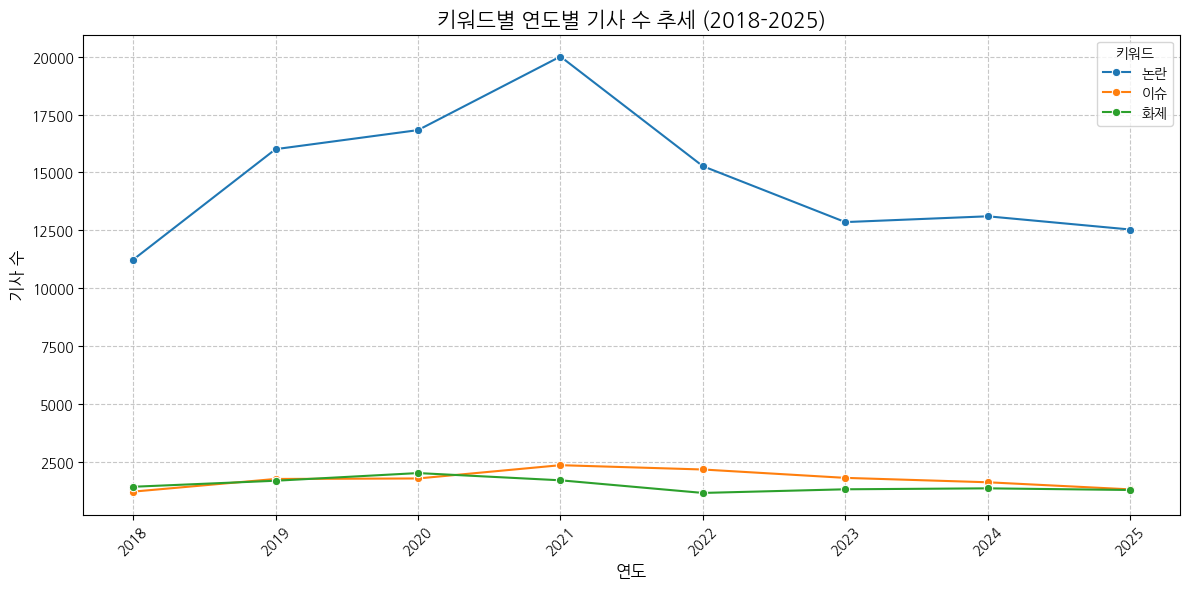

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 그리기
fig = plt.figure(figsize=(12, 6))
sns.lineplot(data=article_counts_df, x='연도', y='기사_수', hue='키워드', marker='o')

plt.title('키워드별 연도별 기사 수 추세 (2018-2025)', fontsize=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('기사 수', fontsize=12)
plt.xticks(article_counts_df['연도'].unique(), rotation=45) # 모든 연도를 x축 틱으로 표시
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='키워드')
plt.tight_layout()
plt.show()


## 2단계: 연어 분석


### 2-1. KoNLPy 설치 및 그래프 함수 설정

In [6]:
# KoNLPy 설치
print("KoNLPy 및 필요한 라이브러리 설치 중...")
!pip install konlpy matplotlib seaborn wordcloud > /dev/null

# Colab 환경에서 일반적으로 사용 가능한 Java 11을 설치합니다.
!sudo apt-get install openjdk-11-jdk-headless -qq > /dev/null

# 환경 변수 설정
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
print("KoNLPy 설치 및 환경 설정 완료.")

KoNLPy 및 필요한 라이브러리 설치 중...
KoNLPy 설치 및 환경 설정 완료.


In [7]:
from konlpy.tag import Okt
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm.notebook import tqdm # tqdm 라이브러리 임포트

# 폰트 설정 다시 적용
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 형태소 분석기 초기화 (Okt 사용)
okt = Okt()

def extract_collocations(text_series, target_keyword, window_size=3, pos_filter=None, direction='both', stopwords=None):
    """
    주어진 텍스트에서 특정 키워드 주변의 연어를 추출하고 빈도를 계산합니다.
    방향성 (앞/뒤/모두) 및 불용어 필터링 기능을 추가합니다.

    Args:
        text_series (pd.Series): 분석할 문장들이 담긴 Pandas Series.
        target_keyword (str): 연어를 추출할 대상 키워드.
        window_size (int): 키워드 앞뒤로 추출할 단어의 개수 (예: 3이면 앞 3개, 뒤 3개).
        pos_filter (list, optional): 추출할 품사 필터 (예: ['Noun']). None이면 모든 품사.
        direction (str): 'both', 'before', 'after' 중 하나. 연어 추출 방향 지정.
        stopwords (list, optional): 불용어 리스트. 추출된 연어에서 제외할 단어들.

    Returns:
        collections.Counter: 추출된 연어와 그 빈도수를 담은 Counter 객체.
    """
    collocations = Counter()
    if stopwords is None:
        stopwords = []

    for sentence in tqdm(text_series, desc=f"'{target_keyword}' 연어 추출 중"):
        if pd.isna(sentence):
            continue

        tokenized_sentence = okt.pos(str(sentence), norm=False, stem=False)
        keyword_indices = [i for i, (word, pos) in enumerate(tokenized_sentence) if word == target_keyword]

        for idx in keyword_indices:
            # 키워드 앞 부분 연어 추출
            if direction in ['before', 'both']:
                start_idx = max(0, idx - window_size)
                for i in range(start_idx, idx):
                    word, pos = tokenized_sentence[i]
                    if (pos_filter is None or pos in pos_filter) and (word not in stopwords):
                        collocations[word] += 1

            # 키워드 뒷 부분 연어 추출
            if direction in ['after', 'both']:
                end_idx = min(len(tokenized_sentence), idx + window_size + 1)
                for i in range(idx + 1, end_idx):
                    word, pos = tokenized_sentence[i]
                    if (pos_filter is None or pos in pos_filter) and (word not in stopwords):
                        collocations[word] += 1
    return collocations

print("연어 추출 함수 'extract_collocations' 기능 확장 완료.")


연어 추출 함수 'extract_collocations' 기능 확장 완료.


In [8]:
def integrate_sentences_for_keyword(keyword):
    """
    주어진 키워드에 대해 모든 연도의 '추출된_문장' 데이터를 통합합니다.

    Args:
        keyword (str): 통합할 키워드 (예: '논란', '이슈', '화제').

    Returns:
        pd.Series: 통합된 문장 데이터를 담은 Pandas Series.
    """
    integrated_sentences = pd.Series(dtype=object)
    if keyword in all_dfs:
        for year in sorted(all_dfs[keyword].keys()):
            if '추출된_문장' in all_dfs[keyword][year].columns:
                integrated_sentences = pd.concat([integrated_sentences, all_dfs[keyword][year]['추출된_문장']], ignore_index=True)
        print(f"'{keyword}' 키워드에 대한 총 {len(integrated_sentences)}개의 문장 데이터 통합 완료.")
    else:
        print(f"경고: '{keyword}' 키워드에 대한 데이터를 찾을 수 없습니다.")
    return integrated_sentences

def display_collocation_results(title, collocations_counter, top_n=30, keyword_for_wc=None, figsize=(12, 8)):
    """
    연어 분석 결과를 빈도표, 막대 그래프, 워드클라우드로 시각화하여 출력합니다.

    Args:
        title (str): 결과의 제목.
        collocations_counter (collections.Counter): 연어와 빈도를 담은 Counter 객체.
        top_n (int): 표시할 상위 N개 연어.
        keyword_for_wc (str, optional): 워드클라우드 제목에 사용할 키워드. 기본값은 None.
        figsize (tuple): 그래프 크기.
    """
    if not collocations_counter:
        print(f"{title}: 추출된 연어가 없습니다.")
        return

    print(f"\n### {title}")
    print(f"상위 {top_n}개 연어:")

    # 빈도표
    collocations_df = pd.DataFrame(collocations_counter.most_common(top_n), columns=['연어', '빈도'])
    display(collocations_df)

    # 막대그래프
    plt.figure(figsize=figsize)
    sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')
    plt.title(f"{title} (상위 {top_n}개)", fontsize=16)
    plt.xlabel('빈도', fontsize=12)
    plt.ylabel('연어', fontsize=12)
    plt.tight_layout()
    plt.show()

    # 워드클라우드
    if keyword_for_wc:
        wordcloud_title = f"'{keyword_for_wc}' {title.split(' ')[0]} 워드클라우드"
    else:
        wordcloud_title = f"{title.split(' ')[0]} 워드클라우드"

    wc = WordCloud(font_path='NanumGothic', background_color='white', width=800, height=400)
    wordcloud = wc.generate_from_frequencies(collocations_counter)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(wordcloud_title, fontsize=16)
    plt.axis('off')
    plt.show()

print("유틸리티 함수 'integrate_sentences_for_keyword' 및 'display_collocation_results' 정의 완료.")


유틸리티 함수 'integrate_sentences_for_keyword' 및 'display_collocation_results' 정의 완료.


### 2-2. '논란', '이슈', '화제' 연어(명사) 추출 및 시각화

'논란' 키워드에 대한 총 117848개의 문장 데이터 통합 완료.


'논란' 연어 추출 중:   0%|          | 0/117848 [00:00<?, ?it/s]


### '논란' 바로 앞에 오는 명사 연어 분석
상위 30개 연어:


,연어,빈도
0,대한,1572
1,정성,1188
2,이번,1108
3,수사,1080
4,최근,1038
5,형평성,936
6,등,931
7,해,912
8,특혜,889
9,관련,713


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


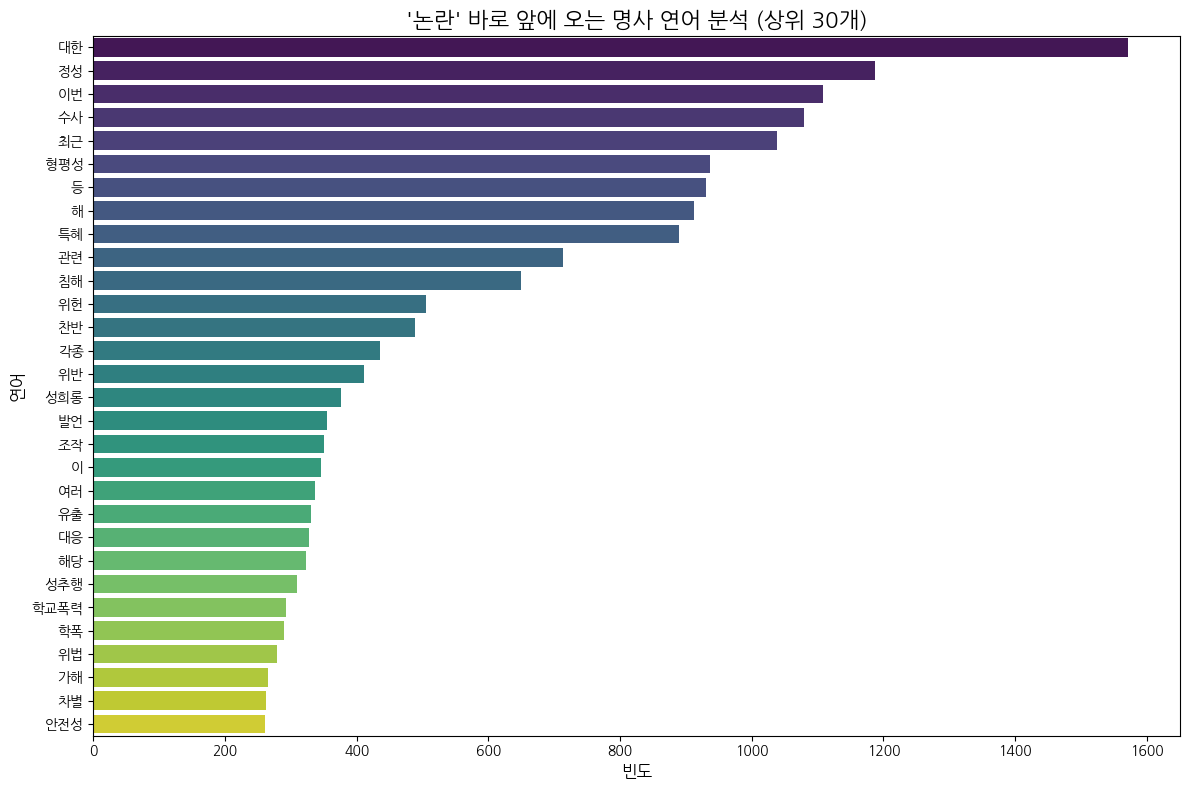

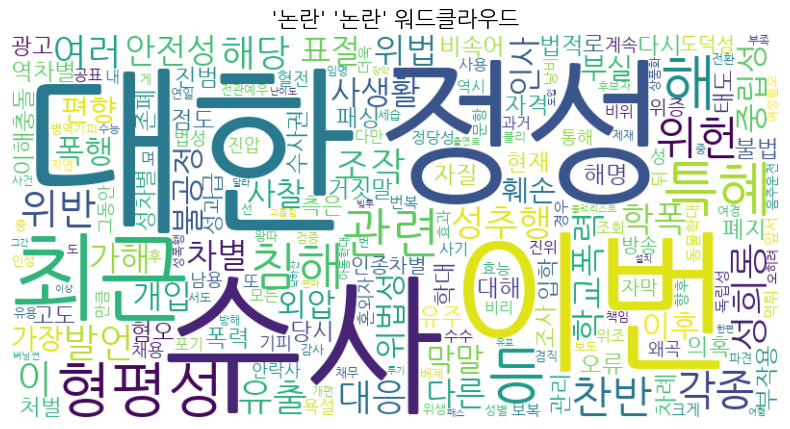

'이슈' 키워드에 대한 총 14155개의 문장 데이터 통합 완료.


'이슈' 연어 추출 중:   0%|          | 0/14155 [00:00<?, ?it/s]


### '이슈' 바로 앞에 오는 명사 연어 분석
상위 30개 연어:


,연어,빈도
0,젠더,484
1,주요,343
2,관련,341
3,사회,329
4,환경,256
5,핵심,141
6,최대,117
7,정치,109
8,노동,108
9,개혁,97


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


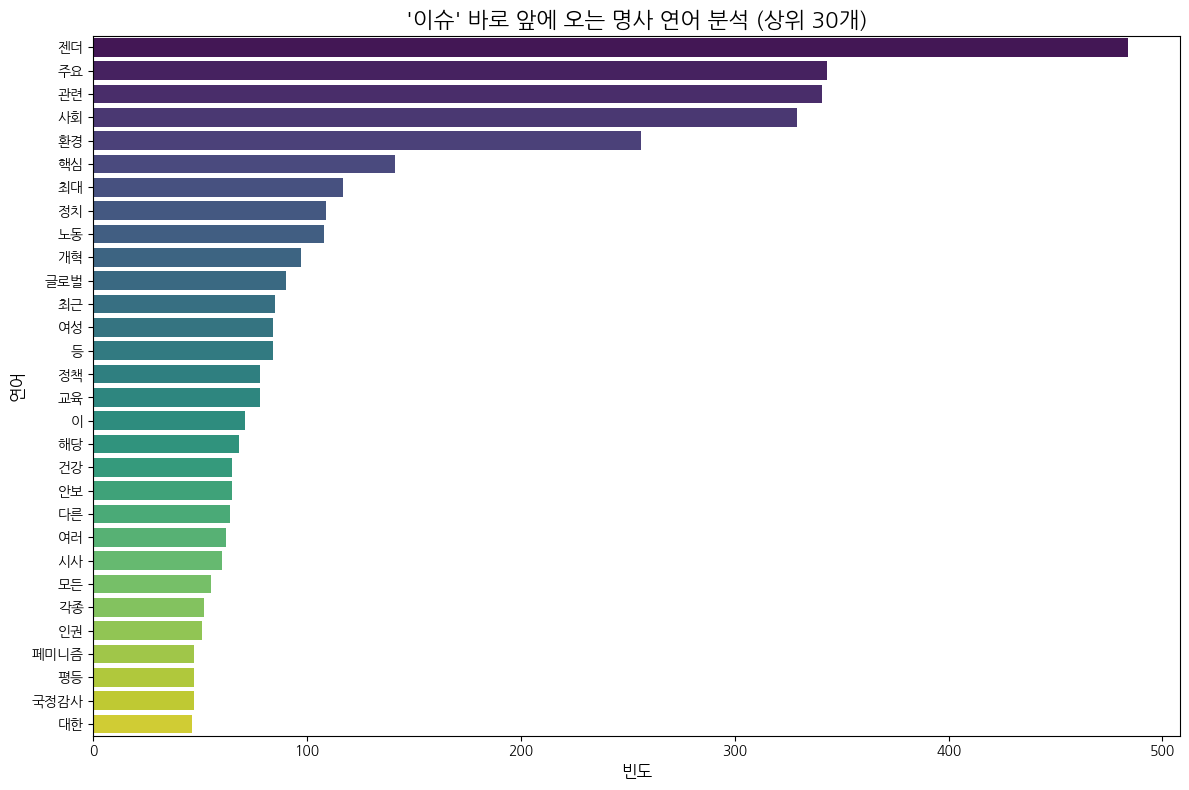

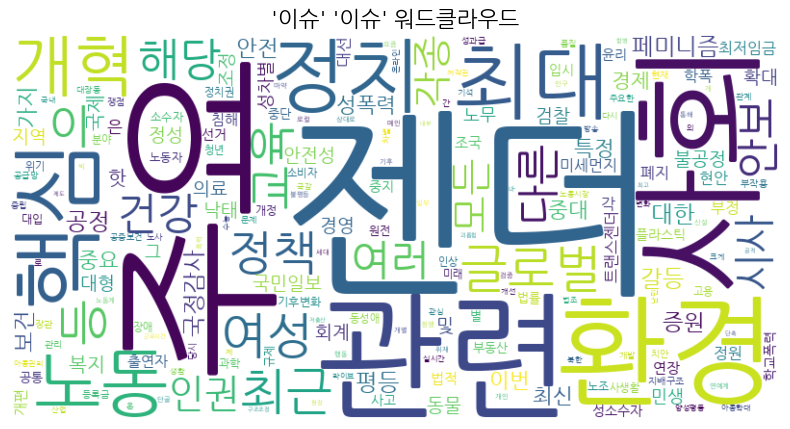

'화제' 키워드에 대한 총 12076개의 문장 데이터 통합 완료.


'화제' 연어 추출 중:   0%|          | 0/12076 [00:00<?, ?it/s]


### '화제' 바로 앞에 오는 명사 연어 분석
상위 30개 연어:


,연어,빈도
0,최근,107
1,이,100
2,해,98
3,전해,69
4,연일,69
5,로,61
6,크게,59
7,등,56
8,다시,53
9,대비,40


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


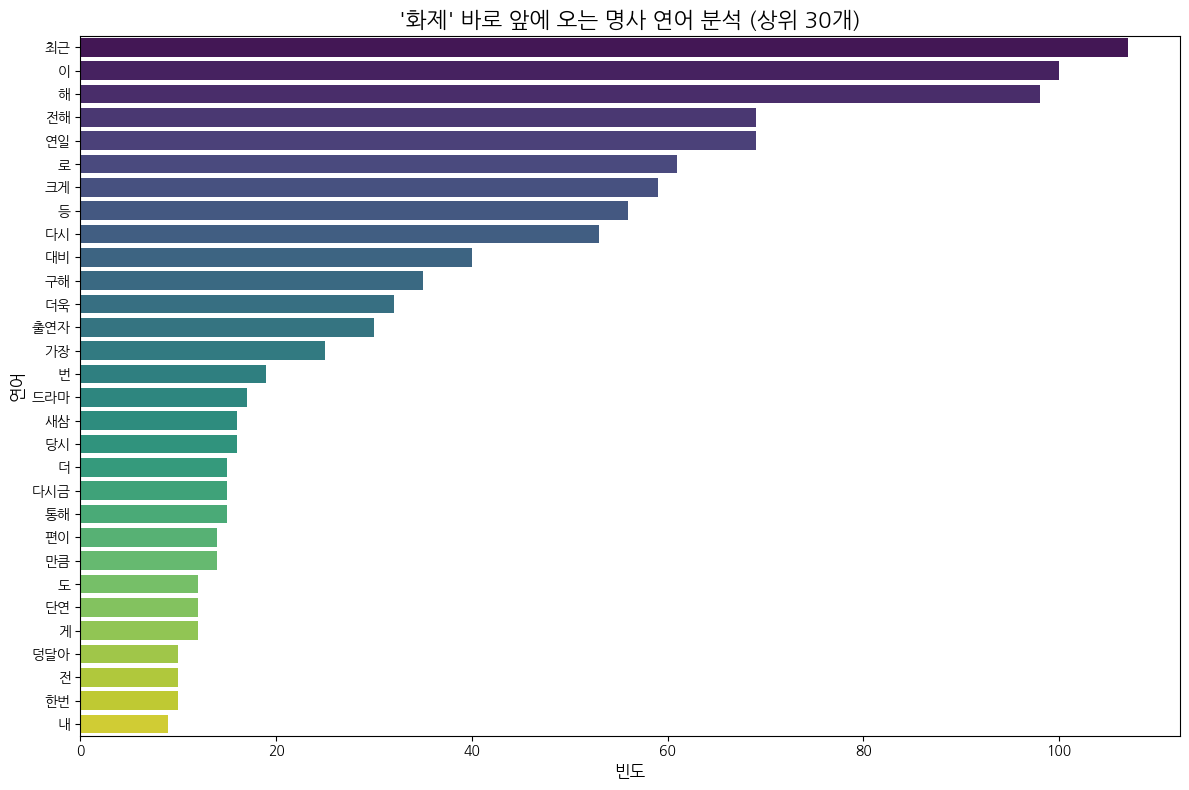

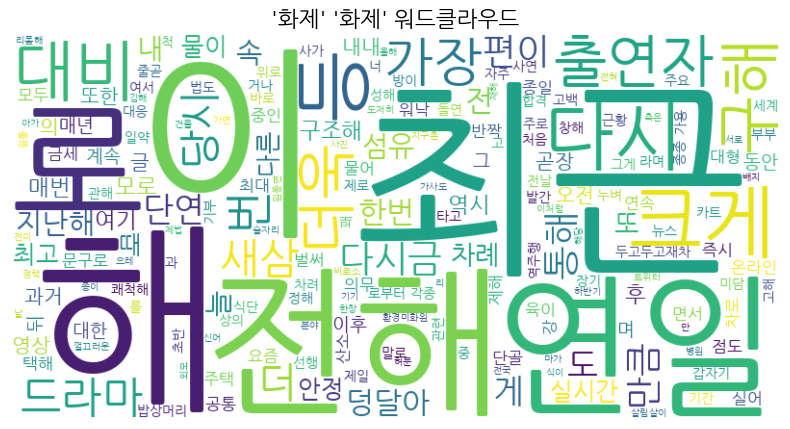

In [9]:
keywords_to_analyze = ['논란', '이슈', '화제']

for keyword in keywords_to_analyze:
    # 1. 키워드별 문장 통합
    sentences = integrate_sentences_for_keyword(keyword)

    # 2. 명사 추출 (window_size=1, direction='before', pos_filter='Noun')
    # 명사만 필터링하도록 'Noun' 품사만 포함
    preceding_nouns = extract_collocations(
        sentences,
        target_keyword=keyword,
        window_size=1,
        pos_filter=['Noun'],
        direction='before'
    )

    # 3. 결과 시각화
    title = f"'{keyword}' 바로 앞에 오는 명사 연어 분석"
    display_collocation_results(title, preceding_nouns, top_n=30, keyword_for_wc=keyword)


### 2-3. 연어 재분석 (불용어 제거 후)

'논란' 키워드에 대한 총 117848개의 문장 데이터 통합 완료.


'논란' 연어 추출 중:   0%|          | 0/117848 [00:00<?, ?it/s]


### '논란' ±3 단어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,수사,2664
1,제기,2507
2,빚,2500
3,일자,2493
4,확산,2140
5,발언,2009
6,사실,1615
7,정성,1324
8,정치,1317
9,부실,1297


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


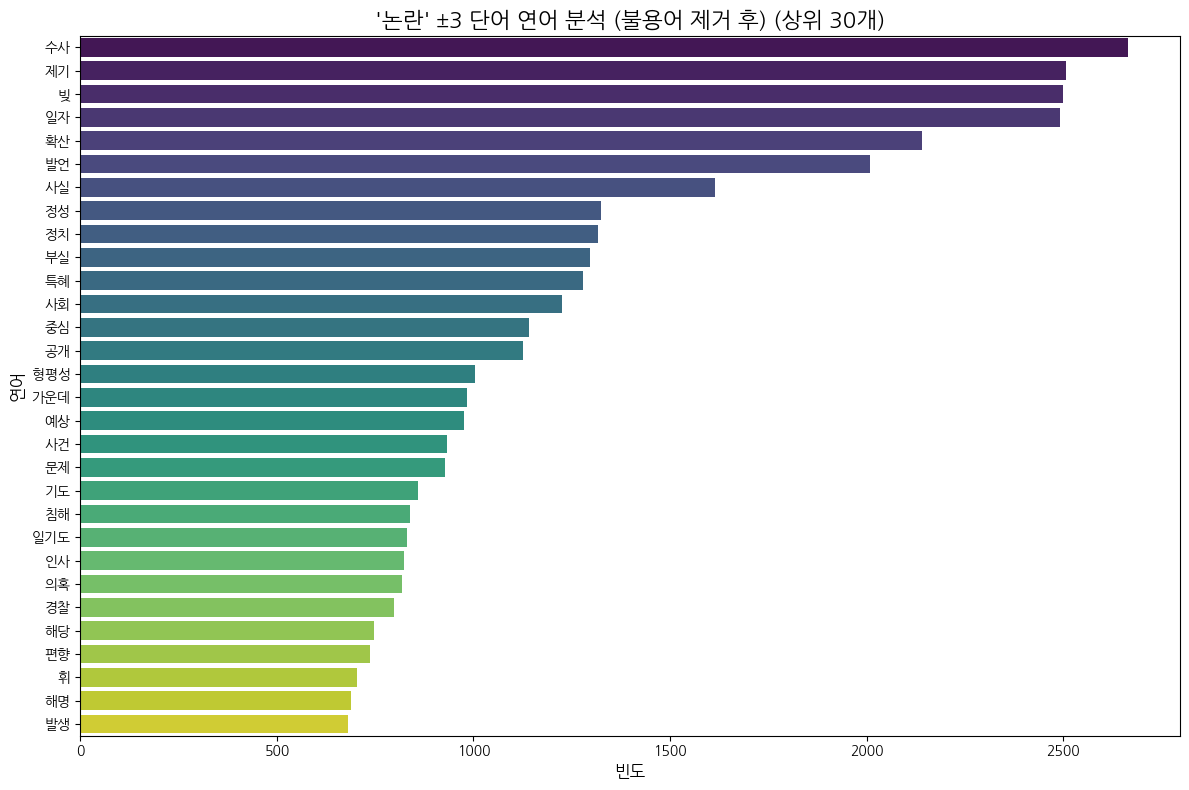

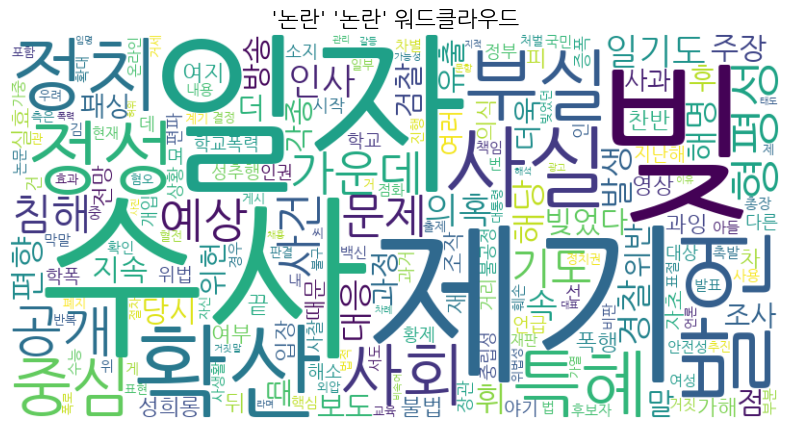

'이슈' 키워드에 대한 총 14155개의 문장 데이터 통합 완료.


'이슈' 연어 추출 중:   0%|          | 0/14155 [00:00<?, ?it/s]


### '이슈' ±3 단어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,사회,1459
1,젠더,553
2,주요,439
3,환경,345
4,정치,339
5,커뮤니티,273
6,탐사,246
7,문제,225
8,여성,198
9,노동,187


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


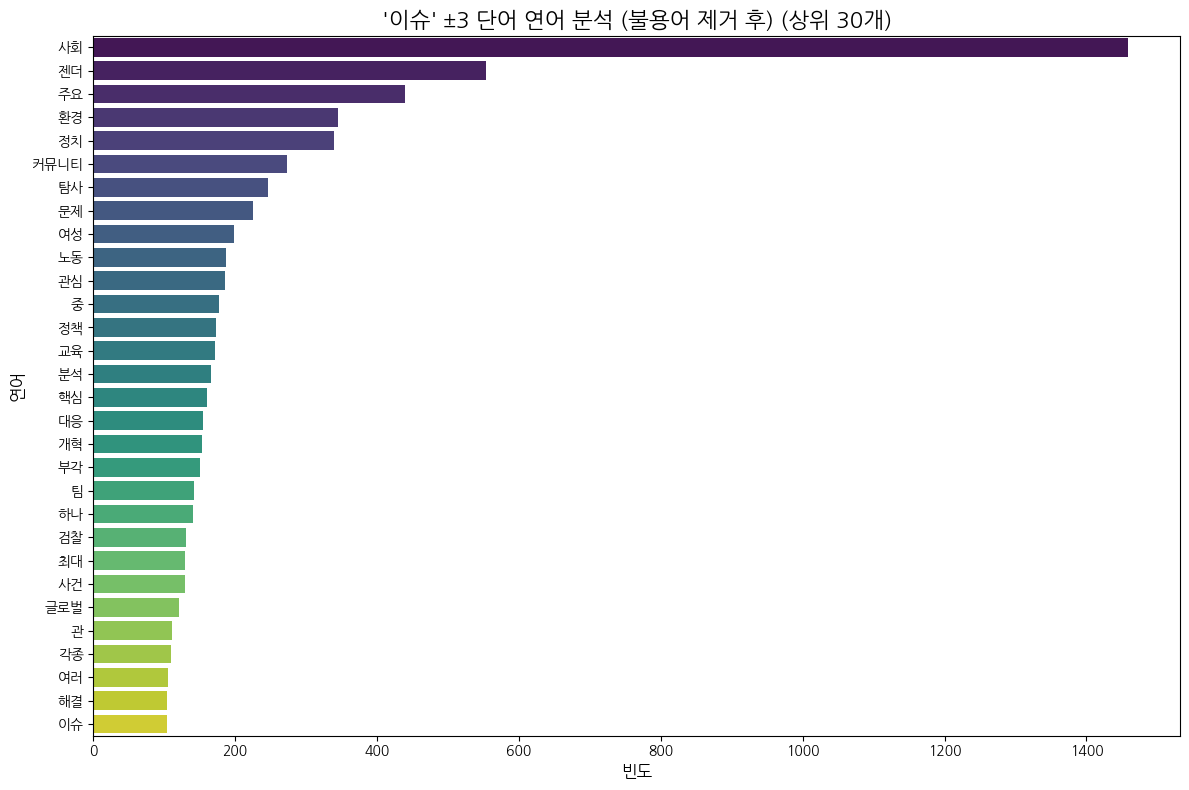

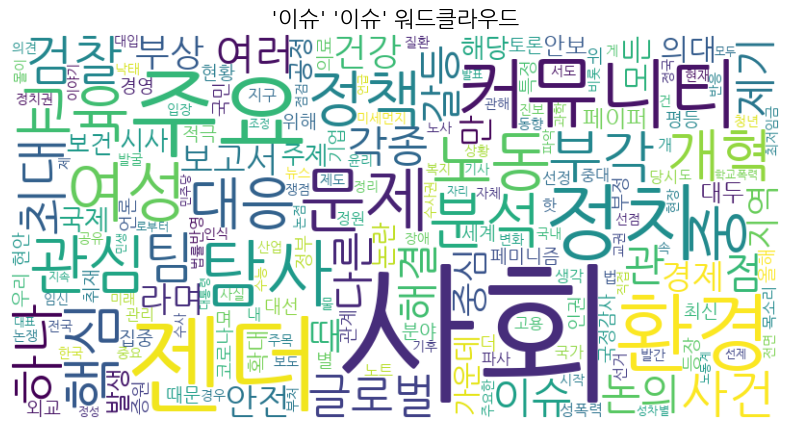

'화제' 키워드에 대한 총 12076개의 문장 데이터 통합 완료.


'화제' 연어 추출 중:   0%|          | 0/12076 [00:00<?, ?it/s]


### '화제' ±3 단어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,기도,534
1,공개,456
2,커뮤니티,448
3,온라인,347
4,사연,253
5,영상,233
6,출연,190
7,모습,145
8,중심,140
9,드라마,138


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


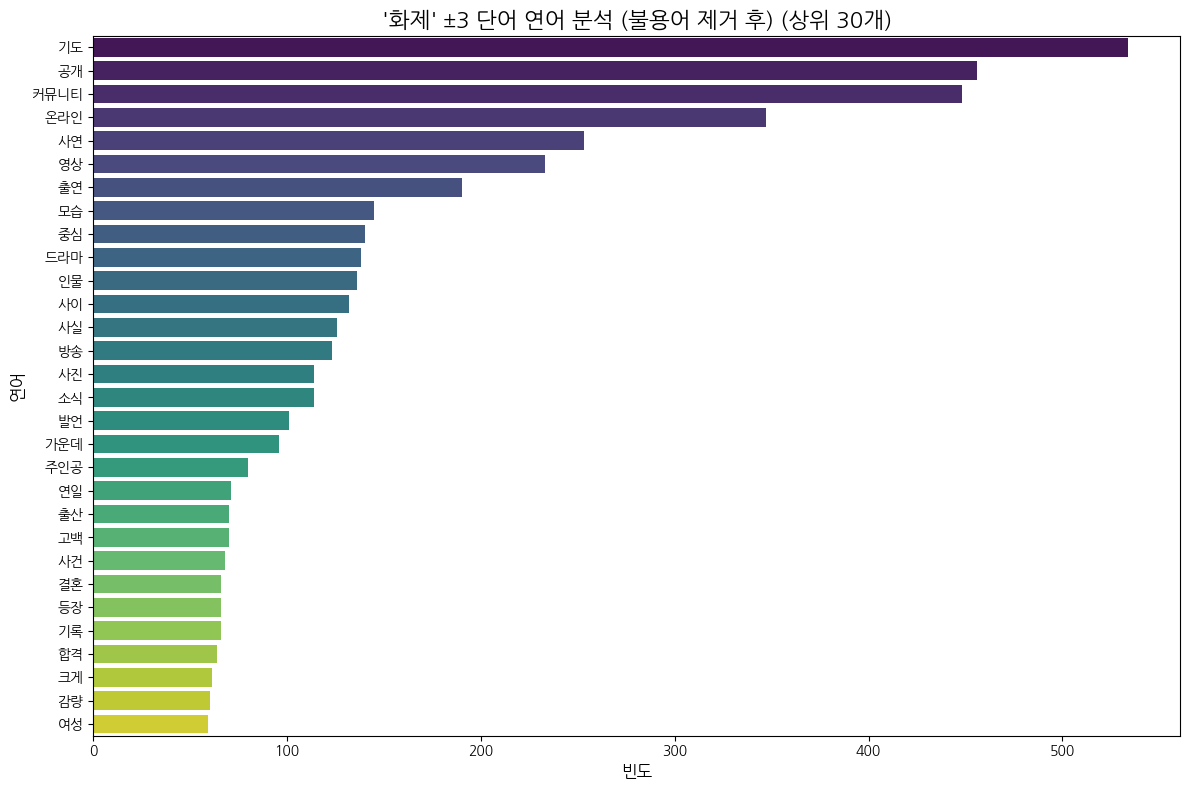

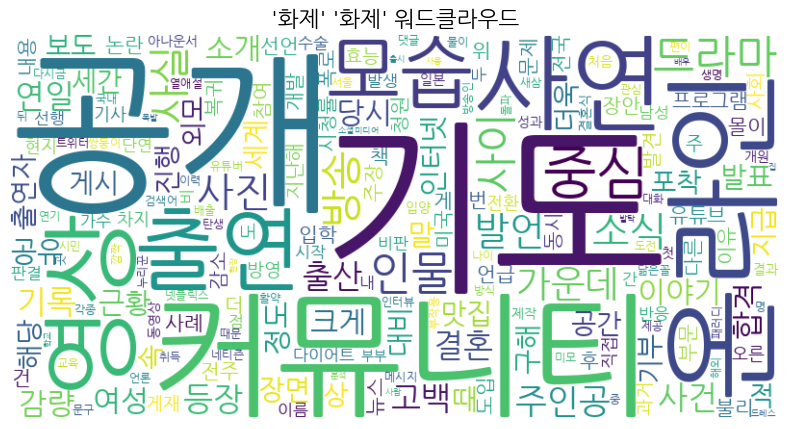

In [20]:
keywords_to_analyze = ['논란', '이슈', '화제']

# 사용자 제공 불용어 리스트
stopwords_list = [
    '것', '수', '등', '일', '대한', '대해', '관련', '있다', '있는', '있어', '이번', '최근',
    '이', '그', '저', '및', '과의', '와의', '부터', '까지', '으로', '으로써', '로서', '로써',
    '에게', '에게서', '한테', '한테서', '이다', '입니다', '하다', '합니다', '하고', '한다',
    '되어', '되다', '된다', '아니', '아니다', '않다', '못하다', '되도록', '가지', '통해',
    '이라고', '라는', '지난', '오전', '오후', '오직', '대부분', '가장', '매우', '아주', '정말',
    '과', '와', '은', '는', '이', '가', '을', '를', '의', '에', '에서', '에게', '로', '으로',
    '과연', '진짜', '참', '반드시', '결국', '마침내', '드디어', '비로소', '점차', '서서히',
    '다시', '또', '계속', '꾸준히', '자주', '언제나', '항상', '간신히', '겨우', '단지', '단순히',
    '아무', '아무나', '아무도', '누구', '누구나', '무엇', '어디', '어느', '어떻게', '왜', '언제',
    '얼마나', '만큼', '함께', '같이', '더불어', '불구하고', '그럼에도', '에도', '다만', '그러나',
    '하지만', '한편', '혹은', '또는', '즉', '곧', '다시', '말하자면', '뿐만', '아니라', '같이',
    '바', '글', '해', '고', '전', '전해', '이후', '불', '중,' '관'
]

for keyword in keywords_to_analyze:
    # 1. 키워드별 문장 통합
    sentences = integrate_sentences_for_keyword(keyword)

    # 2. ±3 단어 연어 추출 (불용어 제거 및 명사만 필터링)
    collocations_filtered_stopwords = extract_collocations(
        sentences,
        target_keyword=keyword,
        window_size=3,
        pos_filter=['Noun'], # 명사만 추출하도록 수정
        direction='both',
        stopwords=stopwords_list
    )

    # 3. 결과 시각화
    title = f"'{keyword}' ±3 단어 연어 분석 (불용어 제거 후)"
    display_collocation_results(title, collocations_filtered_stopwords, top_n=30, keyword_for_wc=keyword)

### 2-4. '논란', '이슈', '화제' 연어(서술어) 추출 및 시각화

'논란' 키워드에 대한 총 117848개의 문장 데이터 통합 완료.


'논란' 연어 추출 중:   0%|          | 0/117848 [00:00<?, ?it/s]


### '논란' 뒤에 오는 서술어 연어 분석
상위 30개 연어:


,연어,빈도
0,이었다,72
1,된,64
2,입니다,31
3,될,29
4,많은,24
5,되자,20
6,휩싸인,18
7,커지자,18
8,이었던,16
9,됐던,15


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


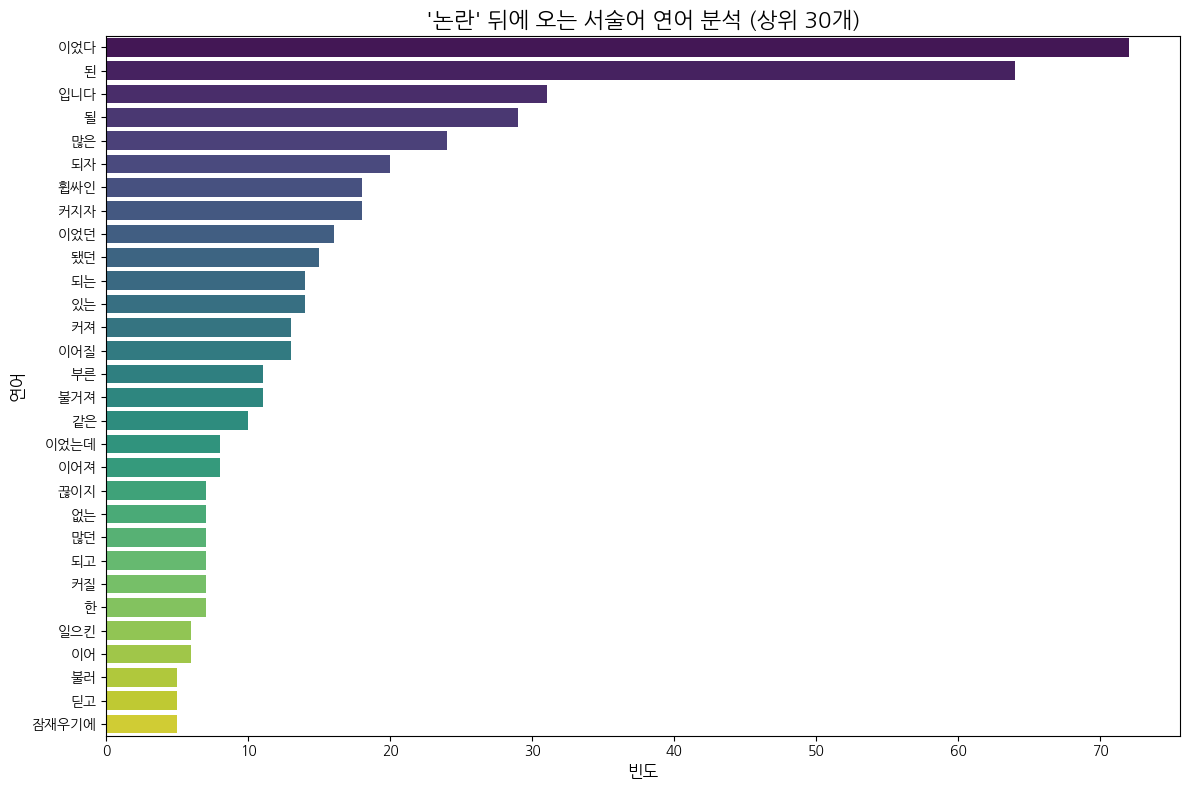

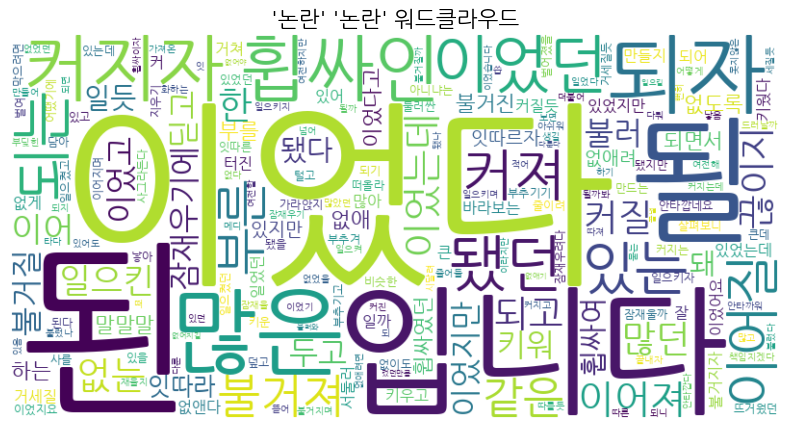

'이슈' 키워드에 대한 총 14155개의 문장 데이터 통합 완료.


'이슈' 연어 추출 중:   0%|          | 0/14155 [00:00<?, ?it/s]


### '이슈' 뒤에 오는 서술어 연어 분석
상위 30개 연어:


,연어,빈도
0,들입니다,358
1,였다,93
2,였던,71
3,입니다,22
4,된,13
5,였는데,11
6,될,8
7,되는,7
8,였지만,7
9,화하는,7


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


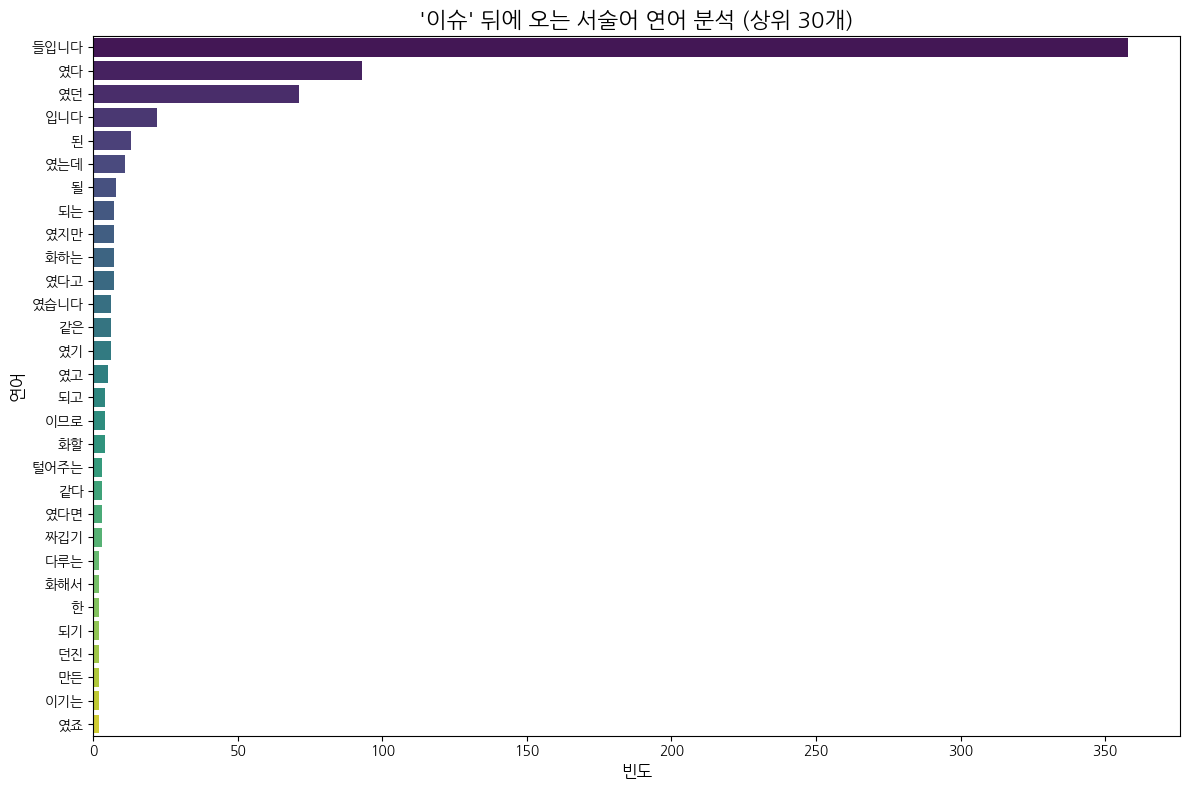

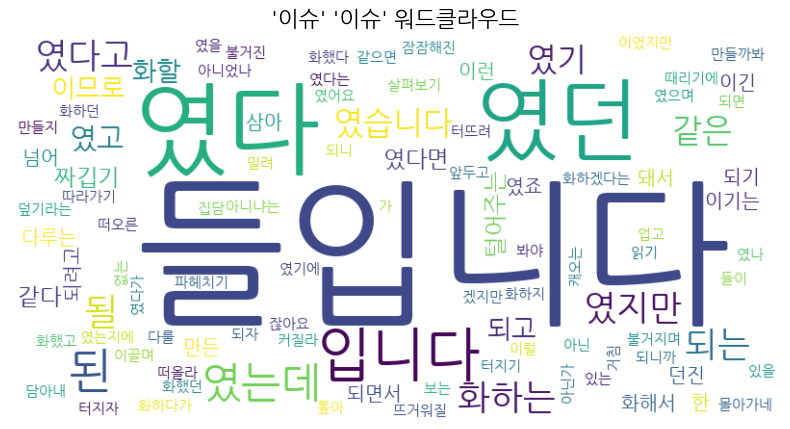

'화제' 키워드에 대한 총 12076개의 문장 데이터 통합 완료.


'화제' 연어 추출 중:   0%|          | 0/12076 [00:00<?, ?it/s]


### '화제' 뒤에 오는 서술어 연어 분석
상위 30개 연어:


,연어,빈도
0,였다,97
1,였던,20
2,입니다,17
3,된,14
4,됐다,8
5,였습니다,6
6,되자,5
7,되고,4
8,였고,4
9,였으나,4


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


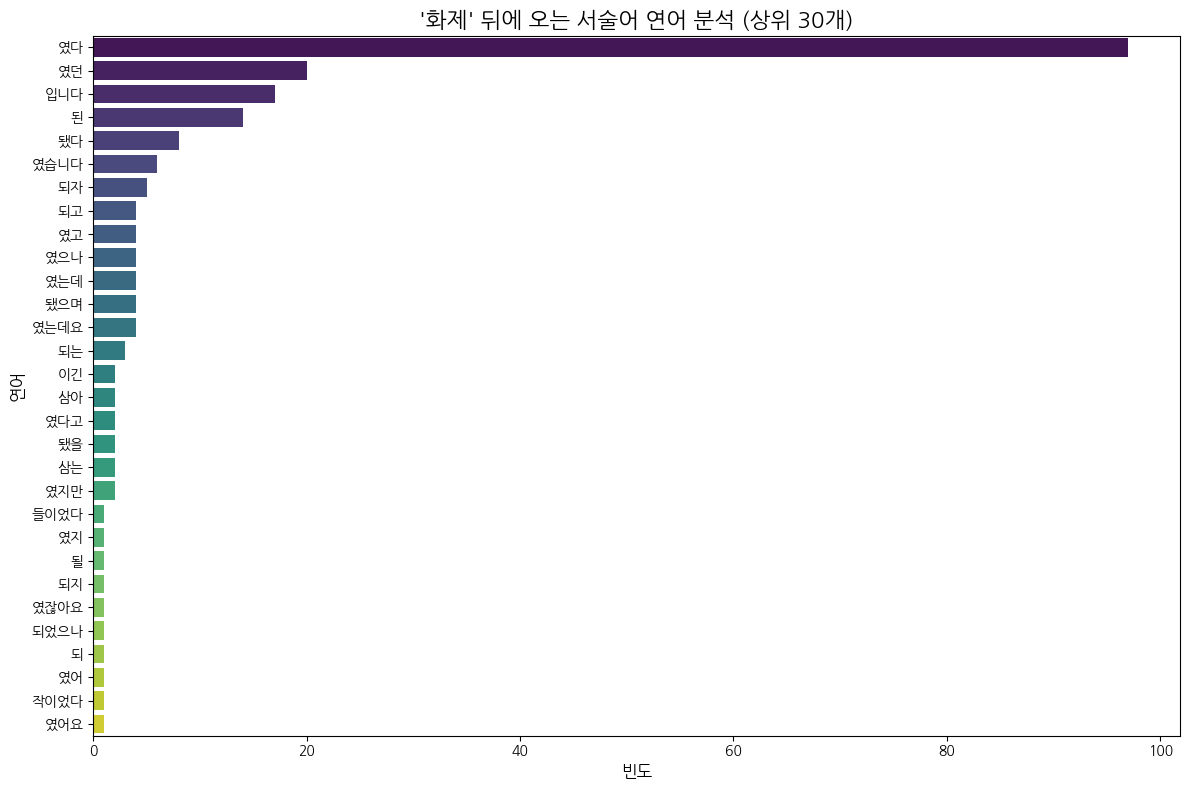

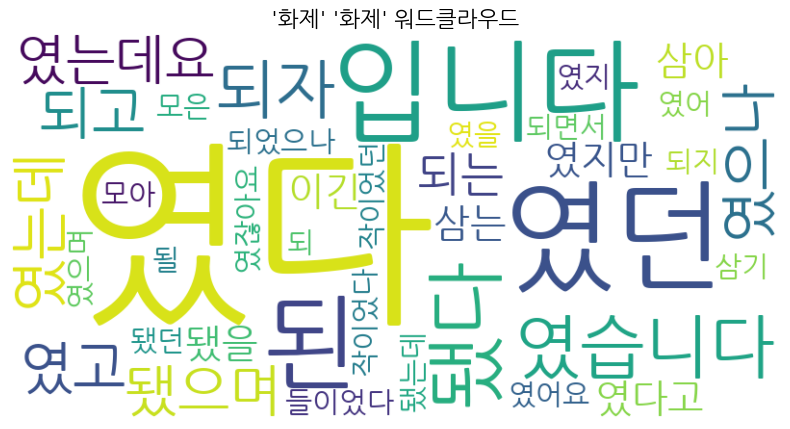

In [10]:
keywords_to_analyze = ['논란', '이슈', '화제']

for keyword in keywords_to_analyze:
    # 1. 키워드별 문장 통합
    sentences = integrate_sentences_for_keyword(keyword)

    # 2. 뒤에 오는 서술어 추출 (window_size=1, direction='after', pos_filter=['Verb', 'Adjective'])
    # 서술어는 동사(Verb)와 형용사(Adjective)를 포함합니다.
    following_predicates = extract_collocations(
        sentences,
        target_keyword=keyword,
        window_size=1,
        pos_filter=['Verb', 'Adjective'],
        direction='after'
    )

    # 3. 결과 시각화
    title = f"'{keyword}' 뒤에 오는 서술어 연어 분석"
    display_collocation_results(title, following_predicates, top_n=30, keyword_for_wc=keyword)


### 2-5. 연어 재분석 (불용어 제거 후)

'논란' 키워드에 대한 총 117848개의 문장 데이터 통합 완료.


'논란' 연어 추출 중:   0%|          | 0/117848 [00:00<?, ?it/s]


### '논란' 뒤에 오는 서술어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,휩싸인,18
1,커지자,18
2,커져,13
3,이어질,13
4,부른,11
5,불거져,11
6,이어져,8
7,끊이지,7
8,없는,7
9,커질,7


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


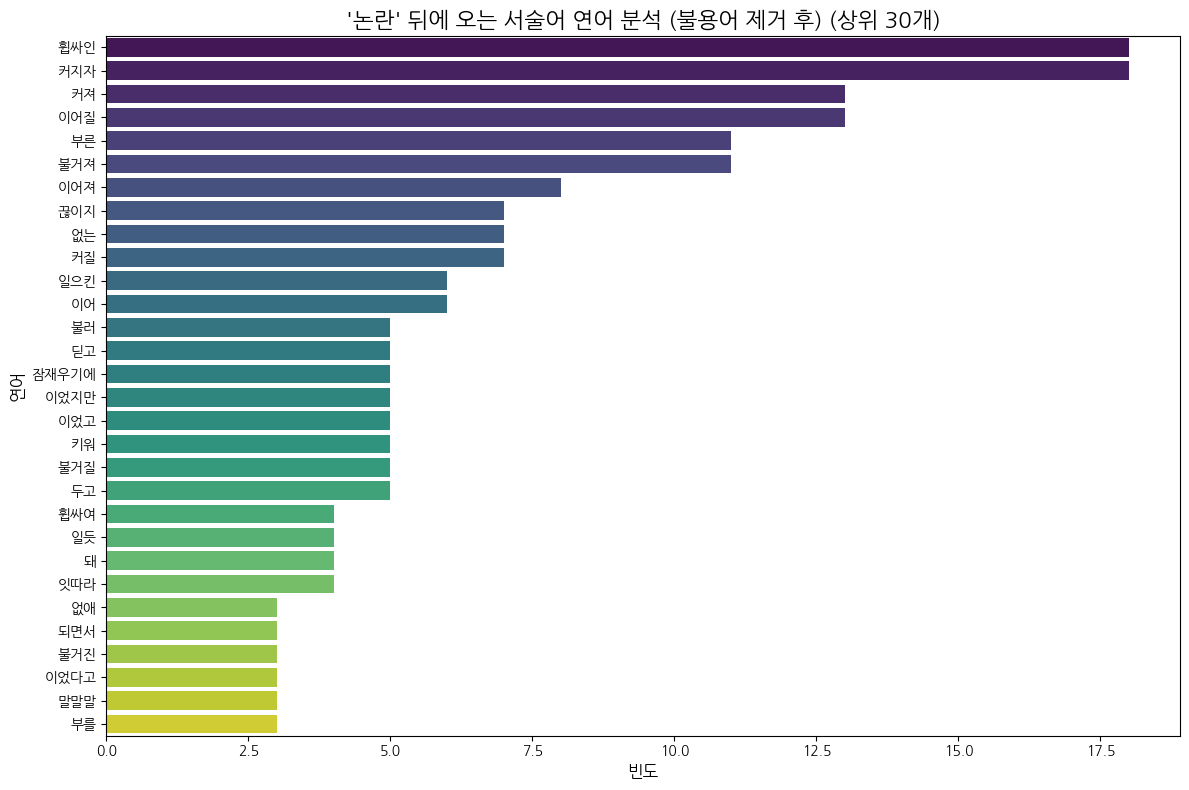

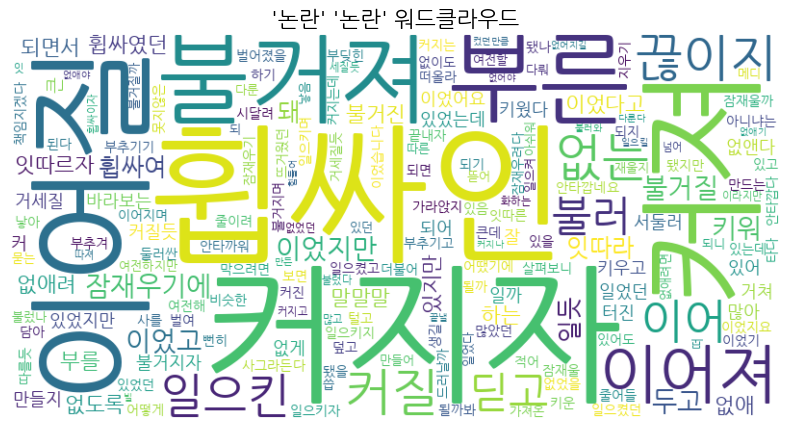

'이슈' 키워드에 대한 총 14155개의 문장 데이터 통합 완료.


'이슈' 연어 추출 중:   0%|          | 0/14155 [00:00<?, ?it/s]


### '이슈' 뒤에 오는 서술어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,들입니다,358
1,였다,93
2,였던,71
3,였는데,11
4,였지만,7
5,화하는,7
6,였다고,7
7,였습니다,6
8,였기,6
9,였고,5


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


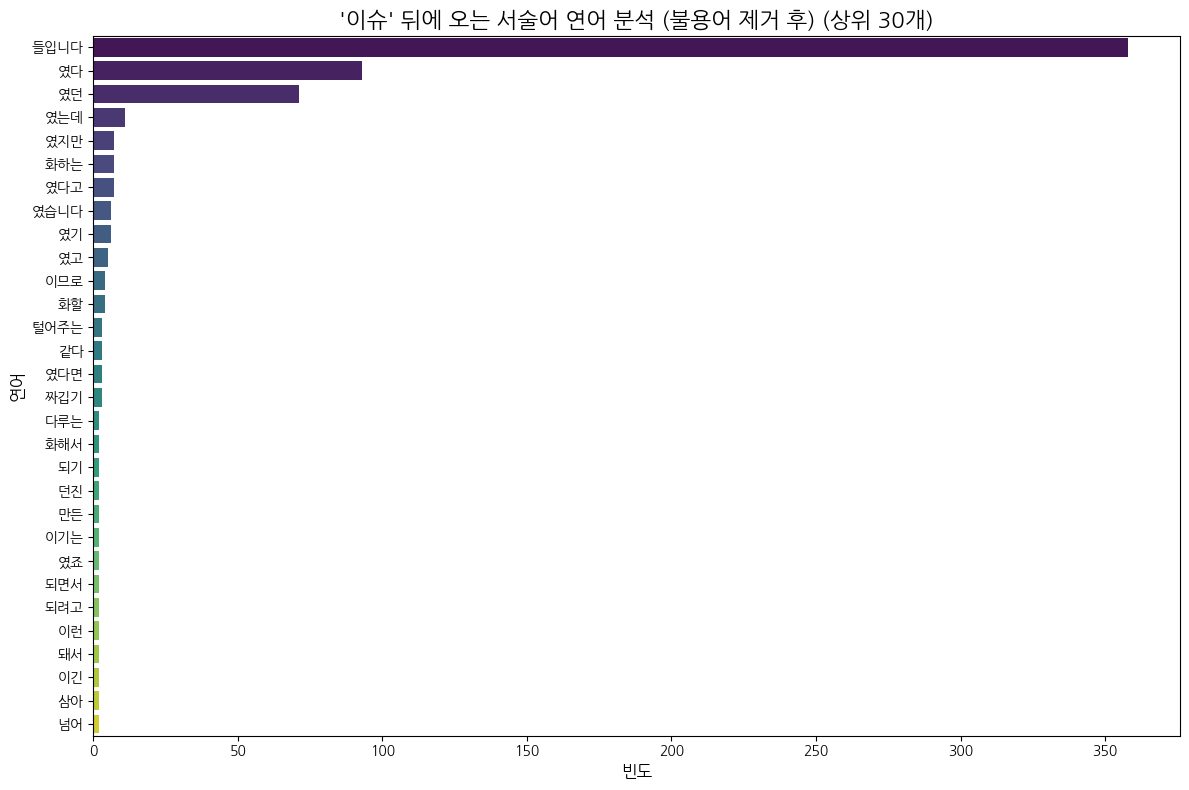

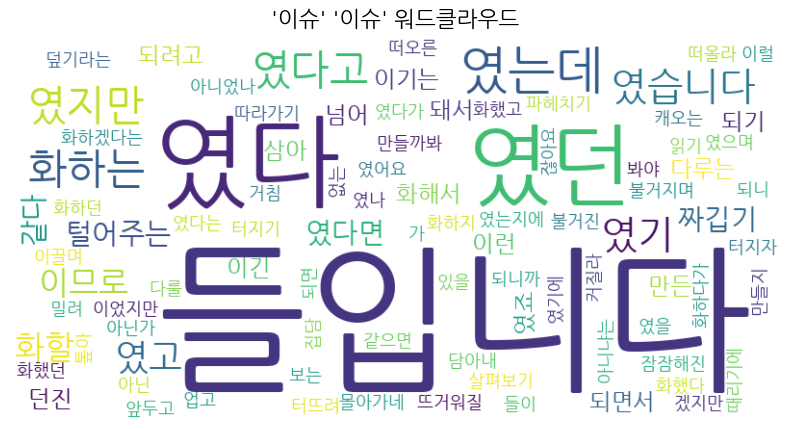

'화제' 키워드에 대한 총 12076개의 문장 데이터 통합 완료.


'화제' 연어 추출 중:   0%|          | 0/12076 [00:00<?, ?it/s]


### '화제' 뒤에 오는 서술어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,였다,97
1,였던,20
2,였습니다,6
3,였고,4
4,였으나,4
5,였는데,4
6,됐으며,4
7,였는데요,4
8,이긴,2
9,삼아,2


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


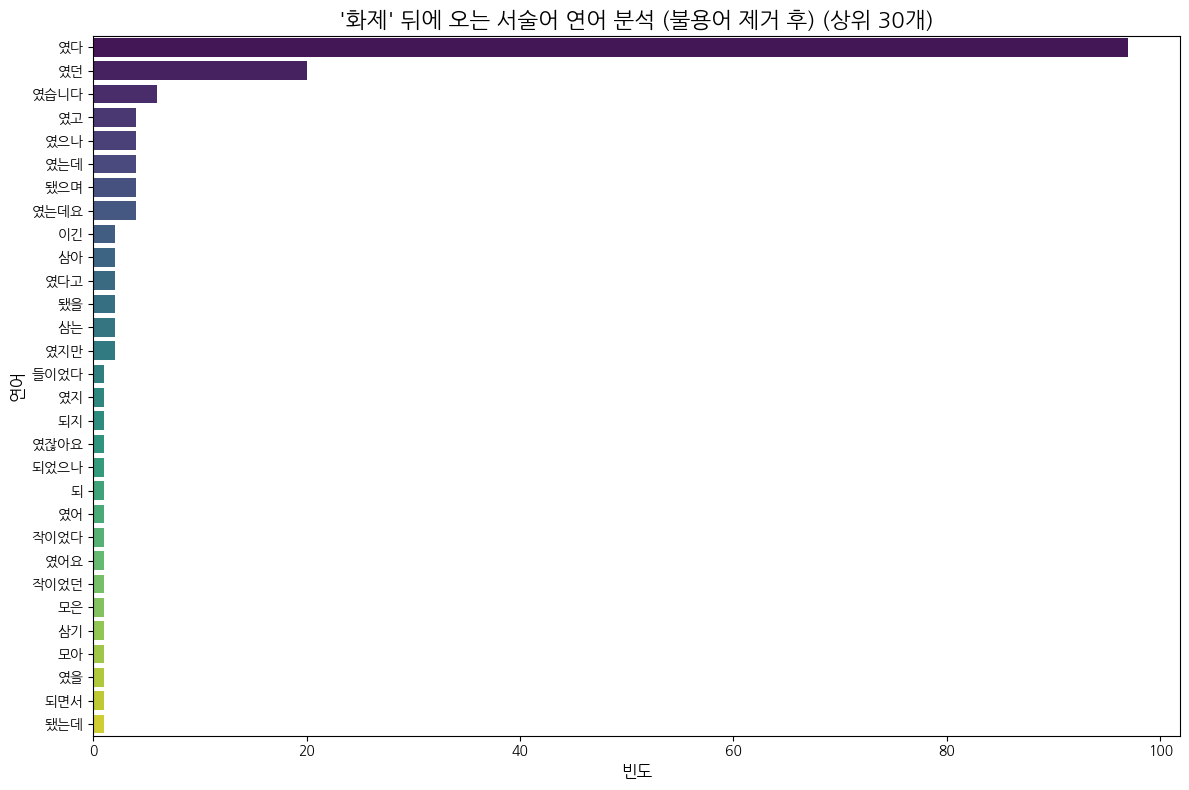

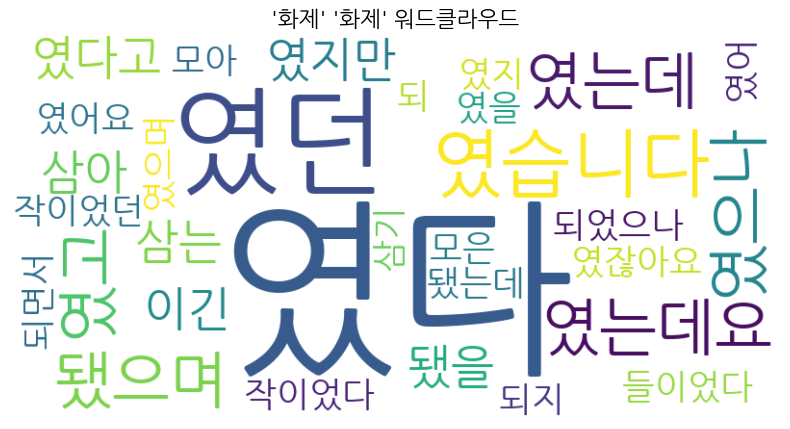

In [22]:
keywords_to_analyze = ['논란', '이슈', '화제']

# 서술어 불용어 리스트 정의
predicate_stopwords_list = [
    '이다', '되다', '있다', '하다', '않다', '없다', '아니다', '말이다',
    '것이다', '하다', '이다', '되다', '이다', '있', '하' '이다', '이었다',
    '이었던', '이었는데', '되다', '된', '되는', '되고', '됐다', '됐던', '될', '되자',
    '있다', '있는', '한', '같은', '많은', '많던', '입니다'
]

for keyword in keywords_to_analyze:
    # 1. 키워드별 문장 통합
    sentences = integrate_sentences_for_keyword(keyword)

    # 2. 뒤에 오는 서술어 추출 (불용어 제거)
    # 서술어는 동사(Verb)와 형용사(Adjective)를 포함합니다.
    following_predicates_filtered = extract_collocations(
        sentences,
        target_keyword=keyword,
        window_size=1,
        pos_filter=['Verb', 'Adjective'],
        direction='after',
        stopwords=predicate_stopwords_list
    )

    # 3. 결과 시각화
    title = f"'{keyword}' 뒤에 오는 서술어 연어 분석 (불용어 제거 후)"
    display_collocation_results(title, following_predicates_filtered, top_n=30, keyword_for_wc=keyword)


'이슈' 키워드에 대한 총 14155개의 문장 데이터 통합 완료.


'이슈' 연어 추출 중:   0%|          | 0/14155 [00:00<?, ?it/s]


### '이슈' 뒤에 오는 서술어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,화하는,7
1,화할,4
2,털어주는,3
3,같다,3
4,였다면,3
5,짜깁기,3
6,다루는,2
7,화해서,2
8,되기,2
9,던진,2


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


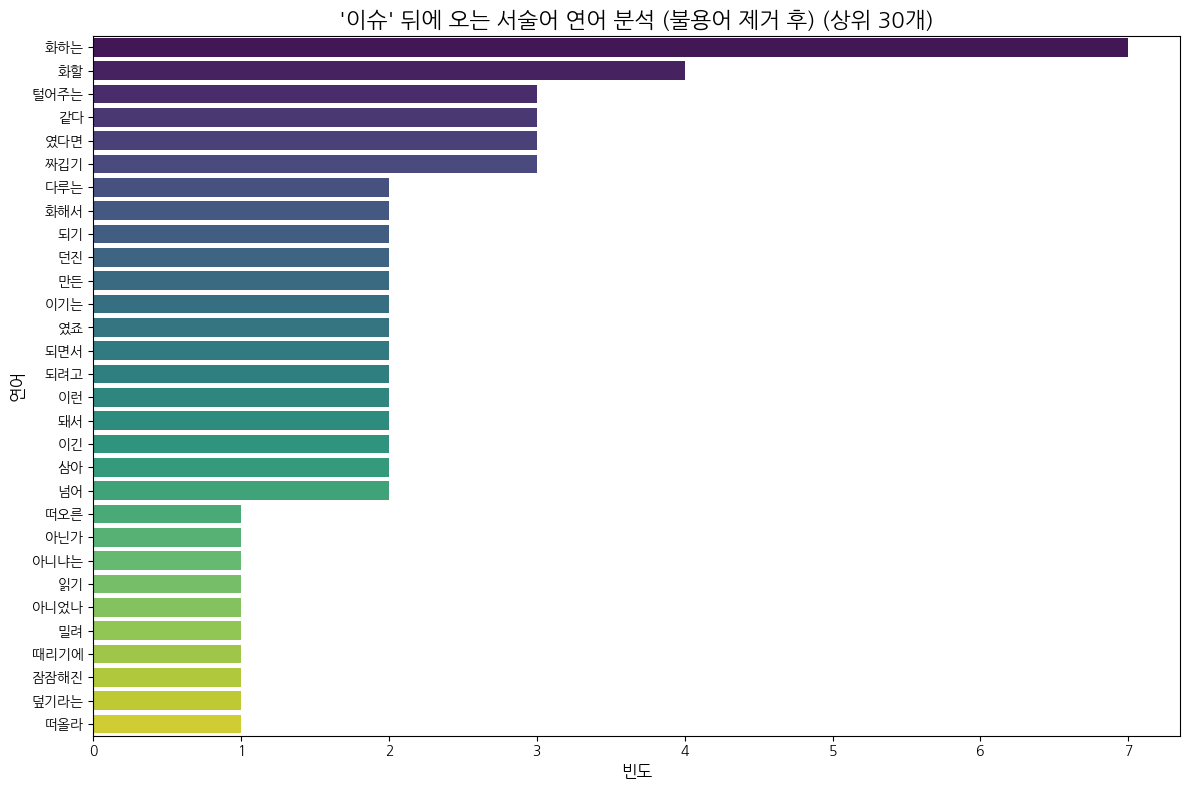

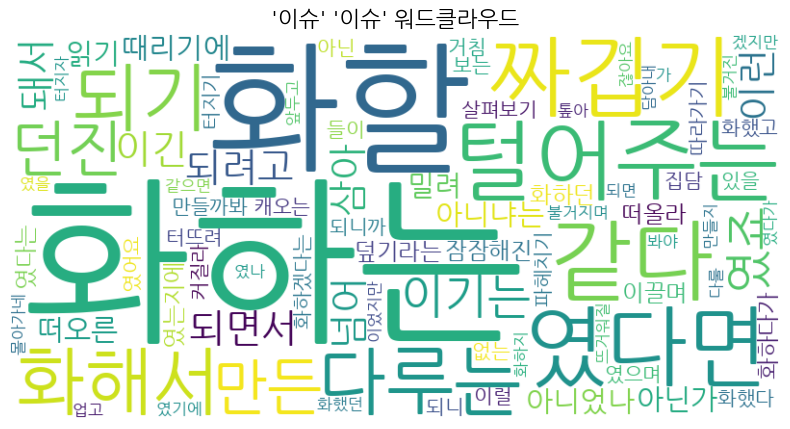

'화제' 키워드에 대한 총 12076개의 문장 데이터 통합 완료.


'화제' 연어 추출 중:   0%|          | 0/12076 [00:00<?, ?it/s]


### '화제' 뒤에 오는 서술어 연어 분석 (불용어 제거 후)
상위 30개 연어:


,연어,빈도
0,였으나,4
1,됐으며,4
2,였는데요,4
3,이긴,2
4,삼아,2
5,됐을,2
6,삼는,2
7,들이었다,1
8,였지,1
9,되지,1


/tmp/ipykernel_17074/775895519.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='빈도', y='연어', data=collocations_df, palette='viridis')


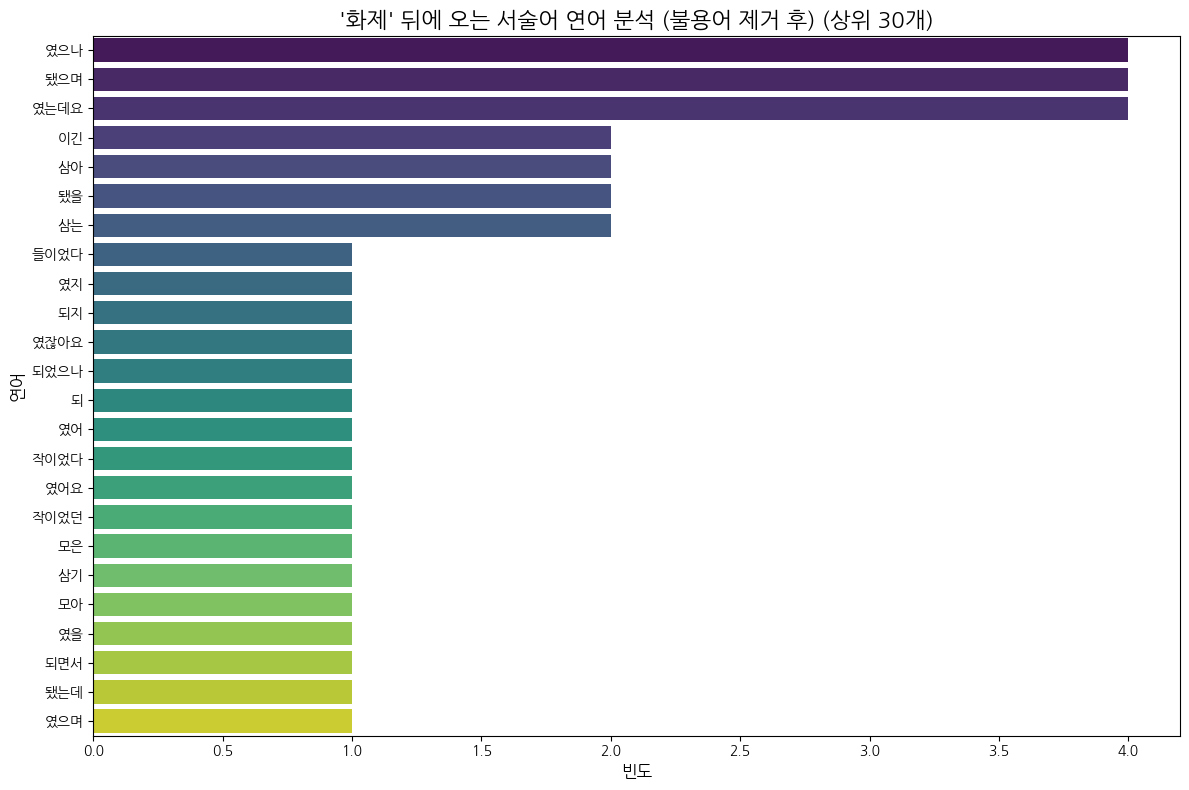

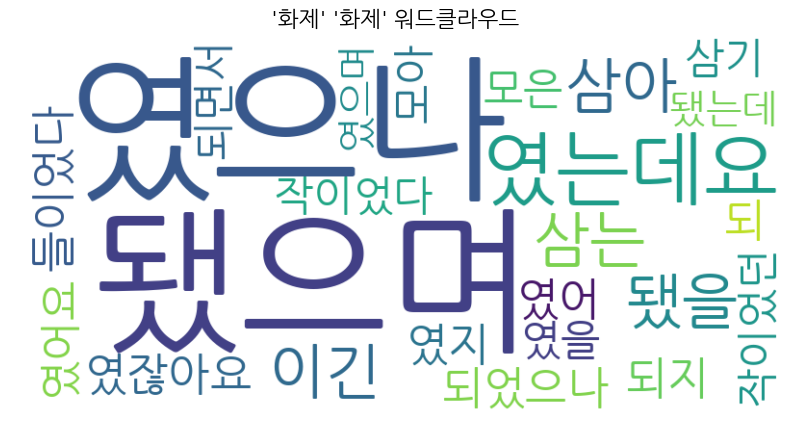

In [24]:
keywords_to_analyze = ['이슈', '화제']

# 서술어 불용어 리스트 정의
predicate_stopwords_list = [
    '이다', '되다', '있다', '하다', '않다', '없다', '아니다', '말이다',
    '것이다', '하다', '이다', '되다', '이다', '있', '하' '이다', '이었다',
    '이었던', '이었는데', '되다', '된', '되는', '되고', '됐다', '됐던', '될', '되자',
    '있다', '있는', '한', '같은', '많은', '많던', '입니다', '들입니다', '였다', '였던', '였는데',
    '였지만', '였다고', '였습니다', '였기', '였고', '이므로'
]

for keyword in keywords_to_analyze:
    # 1. 키워드별 문장 통합
    sentences = integrate_sentences_for_keyword(keyword)

    # 2. 뒤에 오는 서술어 추출 (불용어 제거)
    # 서술어는 동사(Verb)와 형용사(Adjective)를 포함합니다.
    following_predicates_filtered = extract_collocations(
        sentences,
        target_keyword=keyword,
        window_size=1,
        pos_filter=['Verb', 'Adjective'],
        direction='after',
        stopwords=predicate_stopwords_list
    )

    # 3. 결과 시각화
    title = f"'{keyword}' 뒤에 오는 서술어 연어 분석 (불용어 제거 후)"
    display_collocation_results(title, following_predicates_filtered, top_n=30, keyword_for_wc=keyword)


## 3단계: 감성 분석


### 3-1. 감성 분석 수행 및 결과 저장

In [6]:
import pandas as pd
from tqdm.notebook import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# GPU 사용 가능 여부 확인 및 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용할 디바이스: {device}")

# 사전 학습된 모델과 토크나이저 로드
model_name = "snunlp/KR-FinBert-SC"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

print(f"모델 '{model_name}' 로드 및 '{device}' 디바이스 설정 완료.")

label_map = {0: '중립', 1: '긍정', 2: '부정'}

# 모든 키워드와 연도에 대해 감성 분석 적용
print("모든 키워드와 연도에 대해 감성 분석을 시작합니다... (배치 처리 적용)")

sentiment_results = {}

for keyword in nfc_keywords:
    sentiment_results[keyword] = {}
    if keyword in all_dfs:
        for year in sorted(all_dfs[keyword].keys()):
            df = all_dfs[keyword][year].copy() # 원본 DataFrame 변경 방지를 위해 복사본 사용
            print(f"  '{keyword}' {year}년도 데이터 감성 분석 중 ({len(df)} 문장)... ")

            if '추출된_문장' in df.columns and not df['추출된_문장'].empty:
                all_sentences_for_df = df['추출된_문장'].tolist()
                sentiment_labels = [None] * len(all_sentences_for_df)
                sentiment_scores = [None] * len(all_sentences_for_df)

                sentences_to_process = []
                original_indices_map = []

                for idx, sentence in enumerate(all_sentences_for_df):
                    if pd.isna(sentence) or not isinstance(sentence, str) or not sentence.strip():
                        sentiment_labels[idx] = '중립'
                        sentiment_scores[idx] = 1.0
                    else:
                        sentences_to_process.append(sentence)
                        original_indices_map.append(idx)

                if sentences_to_process:
                    batch_size = 32
                    num_batches = (len(sentences_to_process) + batch_size - 1) // batch_size

                    for i in tqdm(range(num_batches), desc=f"  [{keyword} {year}] sentiment batch processing"):
                        start_idx = i * batch_size
                        end_idx = min((i + 1) * batch_size, len(sentences_to_process))
                        batch_texts = sentences_to_process[start_idx:end_idx]

                        # 시간 감소를 위한 토큰화 및 모델 입력 준비 (배치 처리)
                        inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)

                        with torch.no_grad():
                            outputs = model(**inputs)
                            probabilities = torch.softmax(outputs.logits, dim=1)

                        # 결과 추출 및 원본 DataFrame 인덱스에 매핑
                        predicted_label_ids = torch.argmax(probabilities, dim=1).cpu().numpy()
                        scores = probabilities[torch.arange(len(predicted_label_ids)), predicted_label_ids].cpu().numpy()

                        for j in range(len(batch_texts)):
                            original_df_idx = original_indices_map[start_idx + j]
                            predicted_label = label_map.get(predicted_label_ids[j], '알 수 없음')
                            sentiment_labels[original_df_idx] = predicted_label
                            sentiment_scores[original_df_idx] = scores[j]

                df['감성'] = sentiment_labels
                df['감성_점수'] = sentiment_scores

            else:
                print(f"    경고: '{keyword}' {year}년도 데이터에 '추출된_문장' 컬럼이 없거나 비어 있습니다. 감성 분석을 건너뜁니다.")
                df['감성'] = None
                df['감성_점수'] = None

            sentiment_results[keyword][year] = df
            print(f"  '{keyword}' {year}년도 감성 분석 완료.")
    else:
        print(f"  경고: '{keyword}' 키워드에 대한 데이터가 없습니다.")

print("\n모든 키워드와 연도에 대한 감성 분석 완료.")

# 예시로 '논란' 2025년 데이터의 감성 분석 결과 상위 5개 행을 출력합니다.
if '논란' in sentiment_results and 2025 in sentiment_results['논란'] and sentiment_results['논란'][2025] is not None:
    print("\n'논란' 2025년도 데이터의 감성 분석 결과 예시:")
    display(sentiment_results['논란'][2025].head())
else:
    print("\n'논란' 2025년도 감성 분석 결과를 찾을 수 없거나 데이터가 비어 있습니다.")

사용할 디바이스: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

모델 'snunlp/KR-FinBert-SC' 로드 및 'cuda' 디바이스 설정 완료.
모든 키워드와 연도에 대해 감성 분석을 시작합니다... (배치 처리 적용)
  '논란' 2018년도 데이터 감성 분석 중 (11236 문장)... 


  [논란 2018] sentiment batch processing:   0%|          | 0/351 [00:00<?, ?it/s]

  '논란' 2018년도 감성 분석 완료.
  '논란' 2019년도 데이터 감성 분석 중 (16005 문장)... 


...

  [화제 2024] sentiment batch processing:   0%|          | 0/43 [00:00<?, ?it/s]

  '화제' 2024년도 감성 분석 완료.
  '화제' 2025년도 데이터 감성 분석 중 (1302 문장)... 


  [화제 2025] sentiment batch processing:   0%|          | 0/41 [00:00<?, ?it/s]

  '화제' 2025년도 감성 분석 완료.

모든 키워드와 연도에 대한 감성 분석 완료.

'논란' 2025년도 데이터의 감성 분석 결과 예시:


,언론사,추출된_문장,키워드,연도,URL,감성,감성_점수
0,한국일보,그는 청문회 내내 목소리를 높이거나 국회의 발언 중단 요구를 따르지 않아 논란이 됐다.,논란,2025,https://www.hankookilbo.com/News/Read/A2025123...,중립,0.924541
1,한국일보,A씨는 논란이 일자 취임 7개월 만인 2023년 4월 자진 사임했다.,논란,2025,https://www.hankookilbo.com/News/Read/A2025123...,긍정,0.956476
2,한국일보,최근 불거진 연예인들의 미등록 기획사 논란 의식한 것으로 보여,논란,2025,https://www.hankookilbo.com/News/Read/A2025123...,중립,0.918214
3,한국일보,이 가운데 최근 송강호 최수종 송윤아 설경구 박나래 성시경 이하늬 바다 이지혜 강동...,논란,2025,https://www.hankookilbo.com/News/Read/A2025123...,긍정,0.958049
4,한국일보,이 논란으로 인해 유아인은 현재 활동을 중단했다.,논란,2025,https://www.hankookilbo.com/News/Read/A2025123...,중립,0.998939


### 3-2. 감성 분석 수행 및 결과 시각화

키워드별 감성 분포 (평균 비율):


감성,긍정,중립,부정
키워드,,,
논란,0.342520,0.655055,0.002425
이슈,0.891218,0.100915,0.007867
화제,0.883773,0.077872,0.038355


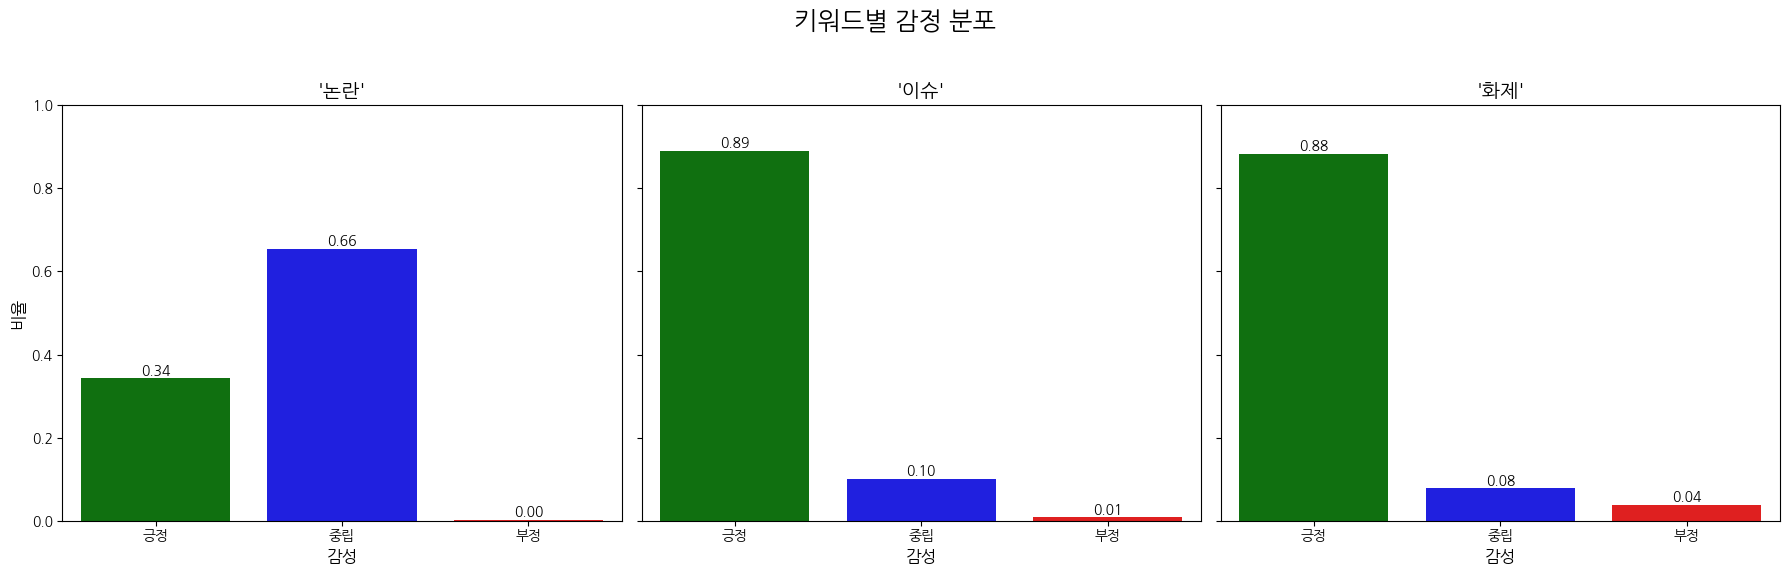

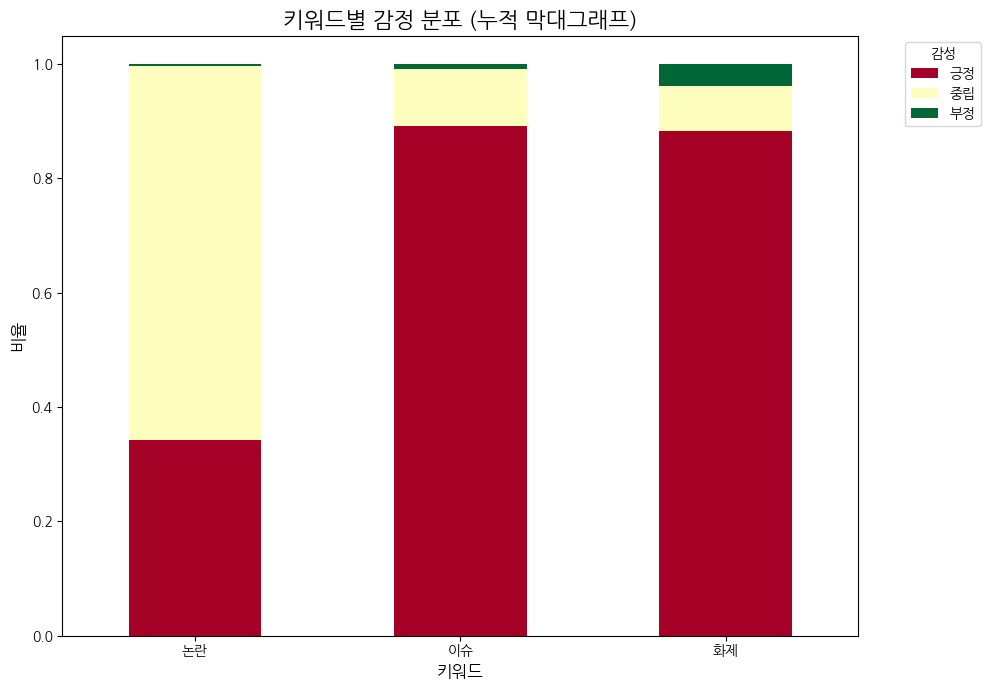

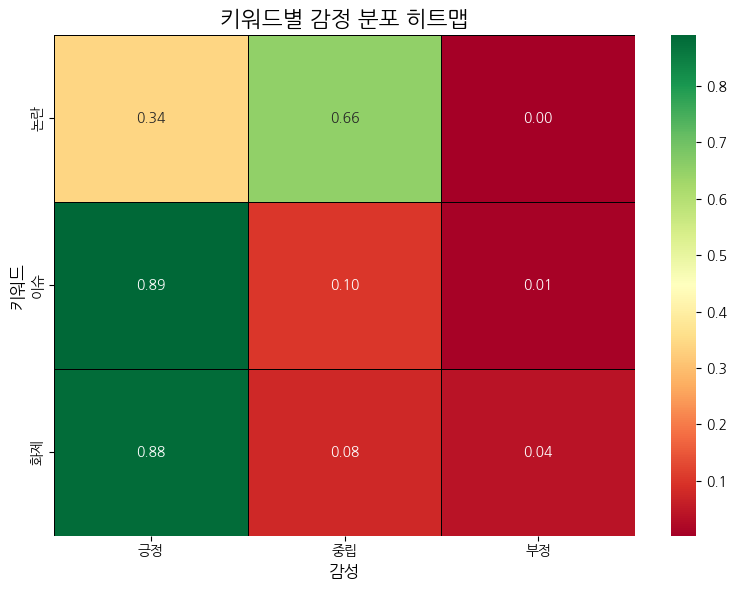

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 폰트 설정 다시 확인
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 감성 분석 결과 집계
# sentiment_results 구조: {keyword: {year: DataFrame with '감성' column}}

sentiment_summary = []

for keyword, years_data in sentiment_results.items():
    for year, df in years_data.items():
        if df is not None and '감성' in df.columns:
            # 각 키워드-연도별 감성 분포 집계
            sentiment_counts = df['감성'].value_counts(normalize=True).reindex(['긍정', '중립', '부정'], fill_value=0)
            for sentiment, proportion in sentiment_counts.items():
                sentiment_summary.append({
                    '키워드': keyword,
                    '연도': year,
                    '감성': sentiment,
                    '비율': proportion
                })

sentiment_df = pd.DataFrame(sentiment_summary)

# 키워드별 전체 감성 분포 (연도 통합)
keyword_sentiment_distribution = sentiment_df.groupby(['키워드', '감성'])['비율'].mean().unstack(fill_value=0)

# '긍정', '중립', '부정' 순서로 정렬
keyword_sentiment_distribution = keyword_sentiment_distribution[['긍정', '중립', '부정']]

print("키워드별 감성 분포 (평균 비율):")
display(keyword_sentiment_distribution)

# 2. 각 키워드별 감정 분포 막대그래프
fig, axes = plt.subplots(1, len(nfc_keywords), figsize=(18, 6), sharey=True)
fig.suptitle('키워드별 감정 분포', fontsize=18)

for i, keyword in enumerate(nfc_keywords):
    data = keyword_sentiment_distribution.loc[keyword]
    # FutureWarning 해결: x를 hue로 전달하고 legend=False 설정
    sns.barplot(x=data.index, y=data.values, hue=data.index, ax=axes[i], palette={'긍정': 'green', '중립': 'blue', '부정': 'red'}, legend=False)
    axes[i].set_title(f"'{keyword}'", fontsize=14)
    axes[i].set_xlabel('감성', fontsize=12)
    axes[i].set_ylabel('비율', fontsize=12) # 첫 번째 그래프에만 Y축 레이블 표시
    axes[i].set_ylim(0, 1) # Y축 범위 통일
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. 세 키워드를 비교할 수 있도록 누적 막대그래프(stacked bar chart)
keyword_sentiment_distribution.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='RdYlGn')
plt.title('키워드별 감정 분포 (누적 막대그래프)', fontsize=16)
plt.xlabel('키워드', fontsize=12)
plt.ylabel('비율', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='감성', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. 감정 분포를 기반으로 heatmap 시각화 (키워드 × 감정 구조)
plt.figure(figsize=(8, 6))
sns.heatmap(keyword_sentiment_distribution, annot=True, fmt=".2f", cmap='RdYlGn', linewidths=.5, linecolor='black')
plt.title('키워드별 감정 분포 히트맵', fontsize=16)
plt.xlabel('감성', fontsize=12)
plt.ylabel('키워드', fontsize=12)
plt.tight_layout()
plt.show()


### 4-1. 연어 관계 기반 경계 분석

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 

--- 명사 연어 재수집 시작 ---
'논란' 키워드에 대한 총 117848개의 문장 데이터 통합 완료.


'논란' 연어 추출 중:   0%|          | 0/117848 [00:00<?, ?it/s]

'논란'의 명사 연어 추출 완료. (총 11661개)
'이슈' 키워드에 대한 총 14155개의 문장 데이터 통합 완료.


'이슈' 연어 추출 중:   0%|          | 0/14155 [00:00<?, ?it/s]

'이슈'의 명사 연어 추출 완료. (총 4328개)
'화제' 키워드에 대한 총 12076개의 문장 데이터 통합 완료.


...

**세 키워드 공통 서술어 연어 (1개):**


['되면서']

  - **해석:** 세 키워드가 공통으로 공유하는 연어의 수가 많지 않다면, 각 담론 프레임이 비교적 독립적인 의미 영역을 가지고 있음을 시사합니다. 반대로 공통 연어가 많다면 프레임 간의 의미적 중첩이 크다고 볼 수 있습니다. 명사 연어는 주로 대상의 공통성을, 서술어 연어는 행위/상태의 공통성을 나타냅니다.

### 3. 키워드 쌍별 Jaccard 유사도


,키워드 쌍,유형,Jaccard 유사도
0,논란-이슈,명사 연어,0.272706
1,논란-이슈,서술어 연어,0.058824
2,논란-화제,명사 연어,0.190929
3,논란-화제,서술어 연어,0.019231
4,이슈-화제,명사 연어,0.238789
5,이슈-화제,서술어 연어,0.060000



### 4. 담론 프레임 경계 유지 및 침투 현상 분석
Jaccard 유사도 수치는 두 키워드의 연어 집합이 얼마나 겹치는지를 0(전혀 겹치지 않음)과 1(완전히 겹침) 사이의 값으로 보여줍니다. 이를 통해 담론 프레임 간의 관계를 분석할 수 있습니다:

**- 높은 유사도 (예: 0.15 이상):** 두 프레임 간의 경계가 상대적으로 모호하며, 한 프레임의 의미 구조가 다른 프레임으로 '침투'하거나 상호 영향을 미치고 있을 가능성이 높습니다. 예를 들어, '논란'과 '이슈' 간의 유사도가 높다면 사회적 의제가 종종 논란의 형태로 나타나거나, 논란이 사회적 의제로 확장되는 경향이 강하다고 해석할 수 있습니다. 이는 '이슈'가 '논란'을 일부 대체하며 사용되고 있는가? 라는 연구 질문에 대한 중요한 단서가 될 수 있습니다.
**- 중간 유사도 (예: 0.05 ~ 0.15):** 두 프레임 간에 어느 정도의 연관성은 있으나, 명확히 구분되는 고유한 영역 또한 존재함을 의미합니다. 부분적인 의미 교류는 있지만, 각 프레임의 정체성은 유지되고 있다고 볼 수 있습니다.
**- 낮은 유사도 (예: 0.05 이하):** 두 프레임 간의 경계가 비교적 명확하게 유지되고 있으며, 각 프레임이 독자적인 의미 영역을 구축하고 있음을 시사합니다. 각 키워드가 매우 다른 맥락에서 사용되고 있음을 의미합니다.

특히 명사 연어와 서술어 연어의 유사도를 분리하여 분석함으로써, 어떤 유형의 단어(객체/개념 vs. 행동/상태)가 프레임 경계에 더 큰 영향을 미치는지 심층적으로 이해할 수 있습니다.

### 5. 키워드별 연어 교집합 시각화 (Venn Diagram)


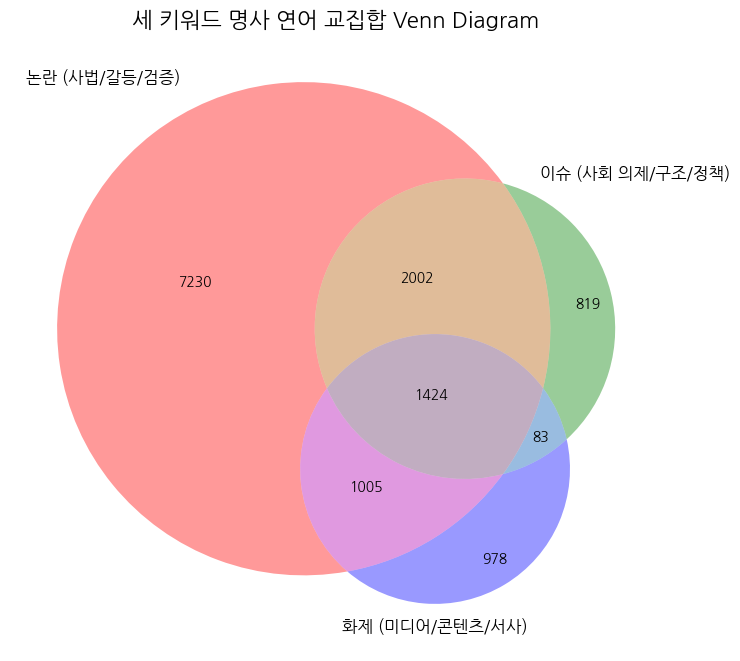

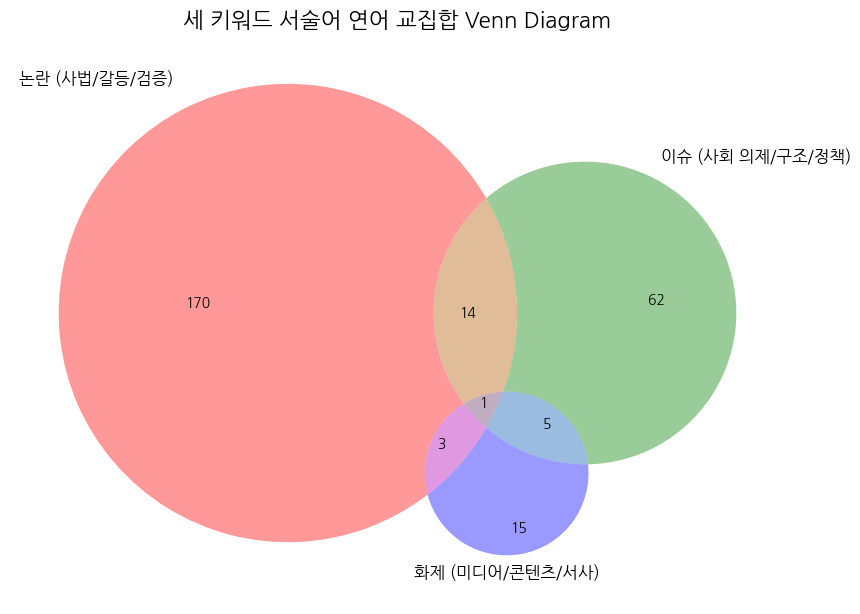


## 담론 프레임 경계 분석 완료.


In [11]:
# KoNLPy 설치 (필요시)
!pip install konlpy > /dev/null

# Colab 환경에서 일반적으로 사용 가능한 Java 11을 설치합니다.
!sudo apt-get install openjdk-11-jdk-headless -qq > /dev/null

# 환경 변수 설정
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from konlpy.tag import Okt
import re
from tqdm.notebook import tqdm # tqdm 라이브러리 임포트

# 폰트 설정 다시 확인
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 형태소 분석기 초기화 (Okt 사용)
okt = Okt()

def extract_collocations(text_series, target_keyword, window_size=3, pos_filter=None, direction='both', stopwords=None):
    """
    주어진 텍스트에서 특정 키워드 주변의 연어를 추출하고 빈도를 계산합니다.
    방향성 (앞/뒤/모두) 및 불용어 필터링 기능을 추가합니다.

    Args:
        text_series (pd.Series): 분석할 문장들이 담긴 Pandas Series.
        target_keyword (str): 연어를 추출할 대상 키워드.
        window_size (int): 키워드 앞뒤로 추출할 단어의 개수 (예: 3이면 앞 3개, 뒤 3개).
        pos_filter (list, optional): 추출할 품사 필터 (예: ['Noun']). None이면 모든 품사.
        direction (str): 'both', 'before', 'after' 중 하나. 연어 추출 방향 지정.
        stopwords (list, optional): 불용어 리스트. 추출된 연어에서 제외할 단어들.

    Returns:
        collections.Counter: 추출된 연어와 그 빈도수를 담은 Counter 객체.
    """
    collocations = Counter()
    if stopwords is None:
        stopwords = []

    for sentence in tqdm(text_series, desc=f"'{target_keyword}' 연어 추출 중"):
        if pd.isna(sentence):
            continue

        tokenized_sentence = okt.pos(str(sentence), norm=False, stem=False)
        keyword_indices = [i for i, (word, pos) in enumerate(tokenized_sentence) if word == target_keyword]

        for idx in keyword_indices:
            # 키워드 앞 부분 연어 추출
            if direction in ['before', 'both']:
                start_idx = max(0, idx - window_size)
                for i in range(start_idx, idx):
                    word, pos = tokenized_sentence[i]
                    if (pos_filter is None or pos in pos_filter) and (word not in stopwords):
                        collocations[word] += 1

            # 키워드 뒷 부분 연어 추출
            if direction in ['after', 'both']:
                end_idx = min(len(tokenized_sentence), idx + window_size + 1)
                for i in range(idx + 1, end_idx):
                    word, pos = tokenized_sentence[i]
                    if (pos_filter is None or pos in pos_filter) and (word not in stopwords):
                        collocations[word] += 1
    return collocations

def integrate_sentences_for_keyword(keyword):
    """
    주어진 키워드에 대해 모든 연도의 '추출된_문장' 데이터를 통합합니다.

    Args:
        keyword (str): 통합할 키워드 (예: '논란', '이슈', '화제').

    Returns:
        pd.Series: 통합된 문장 데이터를 담은 Pandas Series.
    """
    integrated_sentences = pd.Series(dtype=object)
    if keyword in all_dfs:
        for year in sorted(all_dfs[keyword].keys()):
            if '추출된_문장' in all_dfs[keyword][year].columns:
                integrated_sentences = pd.concat([integrated_sentences, all_dfs[keyword][year]['추출된_문장']], ignore_index=True)
        print(f"'{keyword}' 키워드에 대한 총 {len(integrated_sentences)}개의 문장 데이터 통합 완료.")
    else:
        print(f"경고: '{keyword}' 키워드에 대한 데이터를 찾을 수 없습니다.")
    return integrated_sentences

# 사용자 제공 불용어 리스트 (명사 연어용)
stopwords_list = [
    '것', '수', '등', '일', '대한', '대해', '관련', '있다', '있는', '있어', '이번', '최근',
    '이', '그', '저', '및', '과의', '와의', '부터', '까지', '으로', '으로써', '로서', '로써',
    '에게', '에게서', '한테', '한테서', '이다', '입니다', '하다', '합니다', '하고', '한다',
    '되어', '되다', '된다', '아니', '아니다', '않다', '못하다', '되도록', '가지', '통해',
    '이라고', '라는', '지난', '오전', '오후', '오직', '대부분', '가장', '매우', '아주', '정말',
    '과', '와', '은', '는', '이', '가', '을', '를', '의', '에', '에서', '에게', '로', '으로',
    '과연', '진짜', '참', '반드시', '결국', '마침내', '드디어', '비로소', '점차', '서서히',
    '다시', '또', '계속', '꾸준히', '자주', '언제나', '항상', '간신히', '겨우', '단지', '단순히',
    '아무', '아무나', '아무도', '누구', '누구나', '무엇', '어디', '어느', '어떻게', '왜', '언제',
    '얼마나', '만큼', '함께', '같이', '더불어', '불구하고', '그럼에도', '에도', '다만', '그러나',
    '하지만', '한편', '혹은', '또는', '즉', '곧', '다시', '말하자면', '뿐만', '아니라', '같이',
    '바', '글', '해', '고', '전', '전해', '이후', '불', '중', '관'
]

# 서술어 불용어 리스트 정의
predicate_stopwords_list = [
    '이다', '되다', '있다', '하다', '않다', '없다', '아니다', '말이다',
    '것이다', '하다', '이다', '되다', '이다', '있', '하', '이다', '이었다',
    '이었던', '이었는데', '되다', '된', '되는', '되고', '됐다', '됐던', '될', '되자',
    '있다', '있는', '한', '같은', '많은', '많던', '입니다', '들입니다', '였다', '였던', '였는데',
    '였지만', '였다고', '였습니다', '였기', '였고', '이므로'
]

# 모든 키워드에 대한 명사 연어 재수집
all_noun_collocations = {}
print("\n--- 명사 연어 재수집 시작 ---")
for keyword in nfc_keywords:
    sentences = integrate_sentences_for_keyword(keyword)
    collocations = extract_collocations(
        sentences,
        target_keyword=keyword,
        window_size=3,
        pos_filter=['Noun'],
        direction='both',
        stopwords=stopwords_list
    )
    all_noun_collocations[keyword] = collocations
    print(f"'{keyword}'의 명사 연어 추출 완료. (총 {len(collocations)}개)")

# 모든 키워드에 대한 서술어 연어 재수집
all_predicate_collocations = {}
print("\n--- 서술어 연어 재수집 시작 ---")
for keyword in nfc_keywords:
    sentences = integrate_sentences_for_keyword(keyword)
    collocations = extract_collocations(
        sentences,
        target_keyword=keyword,
        window_size=1,
        pos_filter=['Verb', 'Adjective'],
        direction='after',
        stopwords=predicate_stopwords_list
    )
    all_predicate_collocations[keyword] = collocations
    print(f"'{keyword}'의 서술어 연어 추출 완료. (총 {len(collocations)}개)")

# Jaccard 유사도 계산 함수
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

# --- 분석 과제 수행 ---

print("\n## 담론 프레임 경계 분석 시작")

# 1. 각 키워드별 공기어 정리 및 핵심 의미 군집 분류 (상위 N개 출력 및 해석)
print("\n### 1. 키워드별 핵심 공기어 (명사 및 서술어) 및 의미 군집")
frame_definitions = {
    '논란': '사법/갈등/검증 프레임 (법률, 분쟁, 진실 규명 등)',
    '이슈': '사회 의제/구조/정책 프레임 (사회 문제, 제도 개선, 정책 방향 등)',
    '화제': '미디어/콘텐츠/서사 프레임 (대중의 관심, 이야기, 미디어 노출 등)'
}

for keyword in nfc_keywords:
    print(f"\n---- '{keyword}' 키워드 ({frame_definitions[keyword]}) ----")

    print("#### 명사 연어 (상위 15개) 및 의미 군집:")
    noun_df = pd.DataFrame(all_noun_collocations[keyword].most_common(15), columns=['연어', '빈도'])
    display(noun_df)
    print(f"  - **의미 군집 분석 (명사):** 상위 명사 연어들을 통해 '{keyword}' 키워드가 어떤 대상, 개념, 주체와 주로 연관되는지 파악할 수 있습니다. 예를 들어, '논란'은 '법원', '검찰', '의혹' 등과, '이슈'는 '정책', '사회', '정부' 등과, '화제'는 '콘텐츠', '방송', '이야기' 등과 관련이 깊을 것으로 예상됩니다. 이들을 통해 해당 프레임의 주요 관심사를 엿볼 수 있습니다.")

    print("#### 서술어 연어 (상위 15개) 및 의미 군집:")
    predicate_df = pd.DataFrame(all_predicate_collocations[keyword].most_common(15), columns=['연어', '빈도'])
    display(predicate_df)
    print(f"  - **의미 군집 분석 (서술어):** 상위 서술어 연어들은 '{keyword}' 키워드를 중심으로 발생하는 행동, 상태, 평가 등을 나타냅니다. 예를 들어, '논란'은 '되다', '불거지다', '확인되다' 등 갈등 상황을 묘사하는 동사가, '이슈'는 '제기하다', '다루다', '개선하다' 등 사회적 논의와 해결 과정을 나타내는 동사가, '화제'는 '모으다', '되다', '끌다' 등 대중의 반응을 나타내는 동사가 두드러질 것입니다. 이는 각 프레임의 역동적인 특성을 보여줍니다.")

# 2. 세 키워드 간 공통 공기어(교집합) 추출
print("\n### 2. 세 키워드 간 공통 공기어 (교집합)")

# Counter 객체를 집합으로 변환
noun_sets = {kw: set(c.keys()) for kw, c in all_noun_collocations.items()}
predicate_sets = {kw: set(c.keys()) for kw, c in all_predicate_collocations.items()}

common_nouns_all = noun_sets['논란'].intersection(noun_sets['이슈'], noun_sets['화제'])
common_predicates_all = predicate_sets['논란'].intersection(predicate_sets['이슈'], predicate_sets['화제'])

print(f"**세 키워드 공통 명사 연어 ({len(common_nouns_all)}개):**")
display(list(common_nouns_all))
print(f"**세 키워드 공통 서술어 연어 ({len(common_predicates_all)}개):**")
display(list(common_predicates_all))
print("  - **해석:** 세 키워드가 공통으로 공유하는 연어의 수가 많지 않다면, 각 담론 프레임이 비교적 독립적인 의미 영역을 가지고 있음을 시사합니다. 반대로 공통 연어가 많다면 프레임 간의 의미적 중첩이 크다고 볼 수 있습니다. 명사 연어는 주로 대상의 공통성을, 서술어 연어는 행위/상태의 공통성을 나타냅니다.")

# 3. 각 키워드 쌍(논란-이슈, 논란-화제, 이슈-화제)의 overlap 정도를 Jaccard similarity로 계산
print("\n### 3. 키워드 쌍별 Jaccard 유사도")

keyword_pairs = [('논란', '이슈'), ('논란', '화제'), ('이슈', '화제')]
jaccard_results = []

for k1, k2 in keyword_pairs:
    # Nouns
    noun_similarity = jaccard_similarity(noun_sets[k1], noun_sets[k2])
    jaccard_results.append({'키워드 쌍': f'{k1}-{k2}', '유형': '명사 연어', 'Jaccard 유사도': noun_similarity})

    # Predicates
    predicate_similarity = jaccard_similarity(predicate_sets[k1], predicate_sets[k2])
    jaccard_results.append({'키워드 쌍': f'{k1}-{k2}', '유형': '서술어 연어', 'Jaccard 유사도': predicate_similarity})

jaccard_df = pd.DataFrame(jaccard_results)
display(jaccard_df)

# 4. overlap 결과를 바탕으로 담론 프레임 간 경계 유지 여부 또는 침투 현상을 분석
print("\n### 4. 담론 프레임 경계 유지 및 침투 현상 분석")
print("Jaccard 유사도 수치는 두 키워드의 연어 집합이 얼마나 겹치는지를 0(전혀 겹치지 않음)과 1(완전히 겹침) 사이의 값으로 보여줍니다. 이를 통해 담론 프레임 간의 관계를 분석할 수 있습니다:\n")

print("**- 높은 유사도 (예: 0.15 이상):** 두 프레임 간의 경계가 상대적으로 모호하며, 한 프레임의 의미 구조가 다른 프레임으로 '침투'하거나 상호 영향을 미치고 있을 가능성이 높습니다. 예를 들어, '논란'과 '이슈' 간의 유사도가 높다면 사회적 의제가 종종 논란의 형태로 나타나거나, 논란이 사회적 의제로 확장되는 경향이 강하다고 해석할 수 있습니다. 이는 '이슈'가 '논란'을 일부 대체하며 사용되고 있는가? 라는 연구 질문에 대한 중요한 단서가 될 수 있습니다.")
print("**- 중간 유사도 (예: 0.05 ~ 0.15):** 두 프레임 간에 어느 정도의 연관성은 있으나, 명확히 구분되는 고유한 영역 또한 존재함을 의미합니다. 부분적인 의미 교류는 있지만, 각 프레임의 정체성은 유지되고 있다고 볼 수 있습니다.")
print("**- 낮은 유사도 (예: 0.05 이하):** 두 프레임 간의 경계가 비교적 명확하게 유지되고 있으며, 각 프레임이 독자적인 의미 영역을 구축하고 있음을 시사합니다. 각 키워드가 매우 다른 맥락에서 사용되고 있음을 의미합니다.")
print("\n특히 명사 연어와 서술어 연어의 유사도를 분리하여 분석함으로써, 어떤 유형의 단어(객체/개념 vs. 행동/상태)가 프레임 경계에 더 큰 영향을 미치는지 심층적으로 이해할 수 있습니다.")

# 5. 시각화 (Venn diagram 또는 네트워크 구조)
print("\n### 5. 키워드별 연어 교집합 시각화 (Venn Diagram)")

try:
    from matplotlib_venn import venn3, venn3_circles

    # 명사 연어 Venn Diagram
    plt.figure(figsize=(10, 8))
    venn3([noun_sets['논란'], noun_sets['이슈'], noun_sets['화제']],
          set_labels=('논란 (사법/갈등/검증)', '이슈 (사회 의제/구조/정책)', '화제 (미디어/콘텐츠/서사)'))
    plt.title('세 키워드 명사 연어 교집합 Venn Diagram', fontsize=16)
    plt.show()

    # 서술어 연어 Venn Diagram
    plt.figure(figsize=(10, 8))
    venn3([predicate_sets['논란'], predicate_sets['이슈'], predicate_sets['화제']],
          set_labels=('논란 (사법/갈등/검증)', '이슈 (사회 의제/구조/정책)', '화제 (미디어/콘텐츠/서사)'))
    plt.title('세 키워드 서술어 연어 교집합 Venn Diagram', fontsize=16)
    plt.show()

except ImportError:
    print("**참고: matplotlib-venn 라이브러리가 설치되어 있지 않아 Venn Diagram 시각화는 건너뜁니다.**")
    print("Venn Diagram을 보려면 '`!pip install matplotlib-venn`' 명령어를 실행한 후 다시 시도해주세요.")
    print("네트워크 구조 시각화는 복잡도가 높고 추가 라이브러리 설치 및 설정이 필요하여 현재 단계에서는 제외되었습니다. Jaccard 유사도 표를 통해 경계 분석을 진행하실 수 있습니다.")

print("\n## 담론 프레임 경계 분석 완료.")


## 연도별 연어 교집합 Venn Diagram 시계열 분석 시작


연도별 Venn Diagram 생성 중:   0%|          | 0/8 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/11236 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/11236 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1231 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1231 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1441 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1441 [00:00<?, ?it/s]

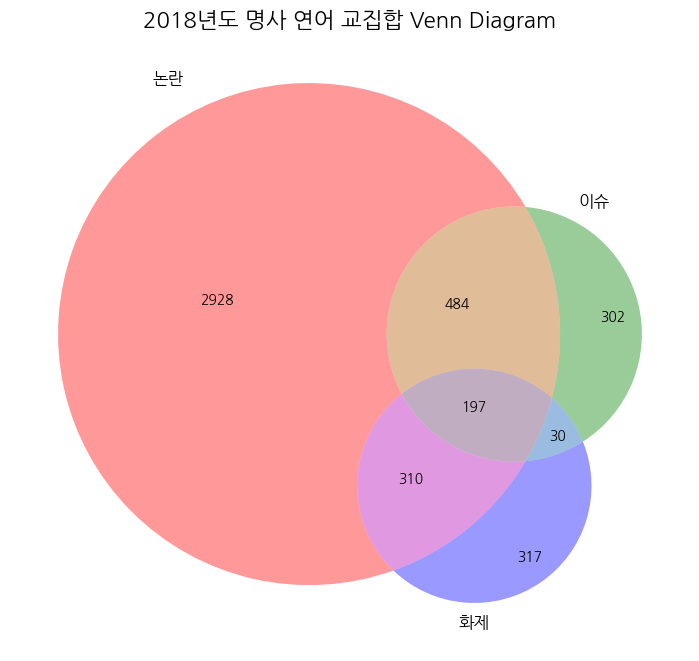

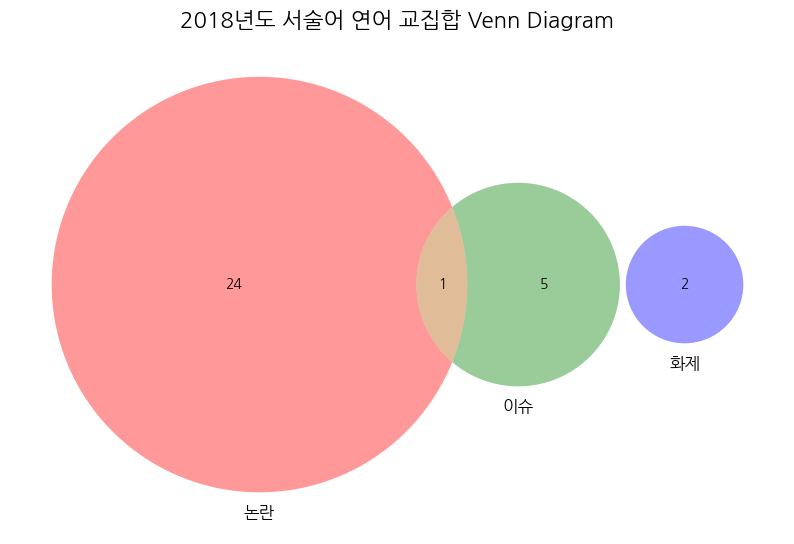

'논란' 연어 추출 중:   0%|          | 0/16005 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/16005 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1778 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1778 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1701 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1701 [00:00<?, ?it/s]

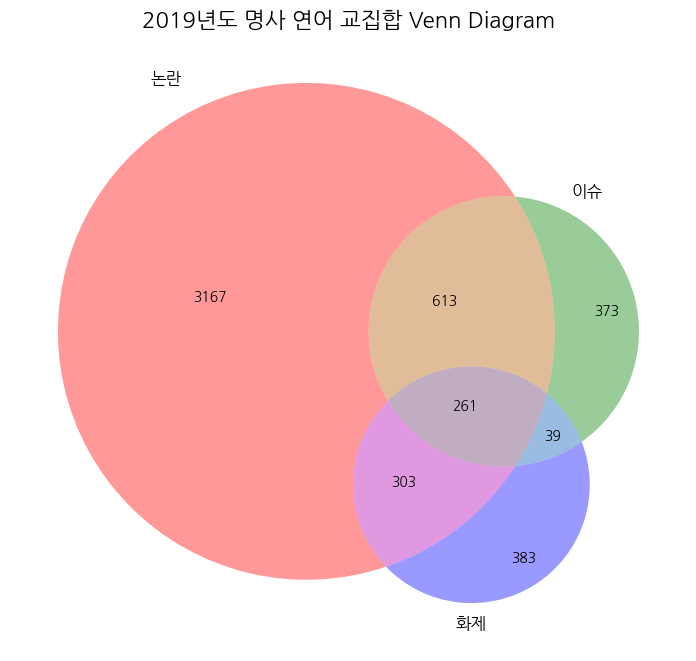

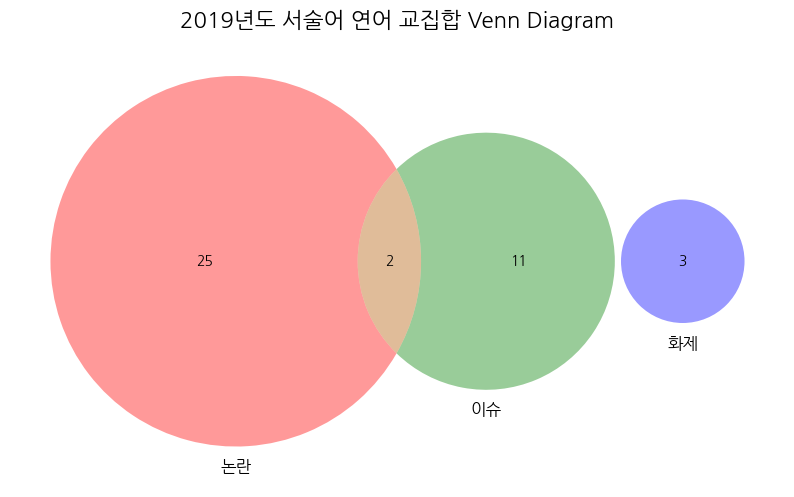

'논란' 연어 추출 중:   0%|          | 0/16827 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/16827 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1799 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1799 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/2032 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/2032 [00:00<?, ?it/s]

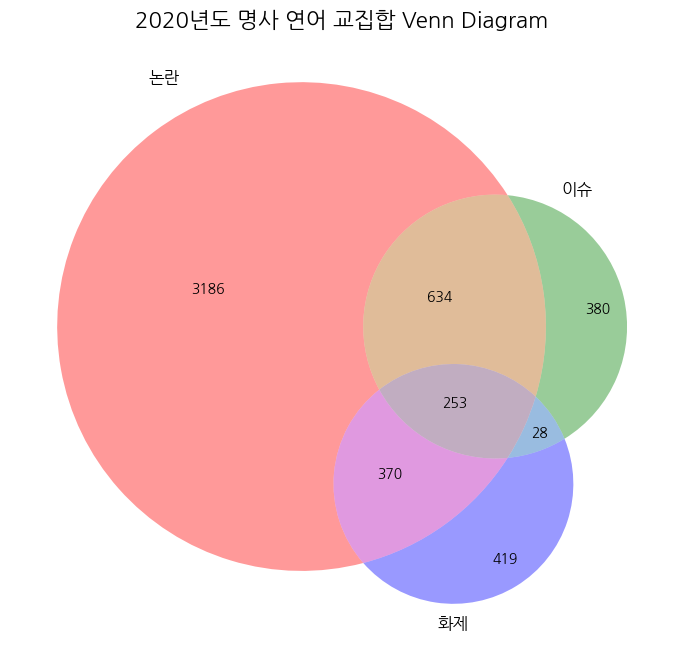

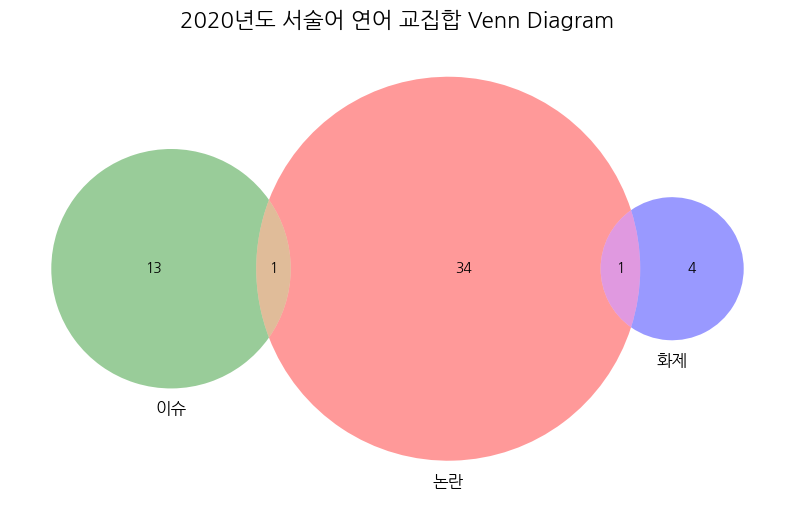

'논란' 연어 추출 중:   0%|          | 0/20002 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/20002 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/2372 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/2372 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1720 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1720 [00:00<?, ?it/s]

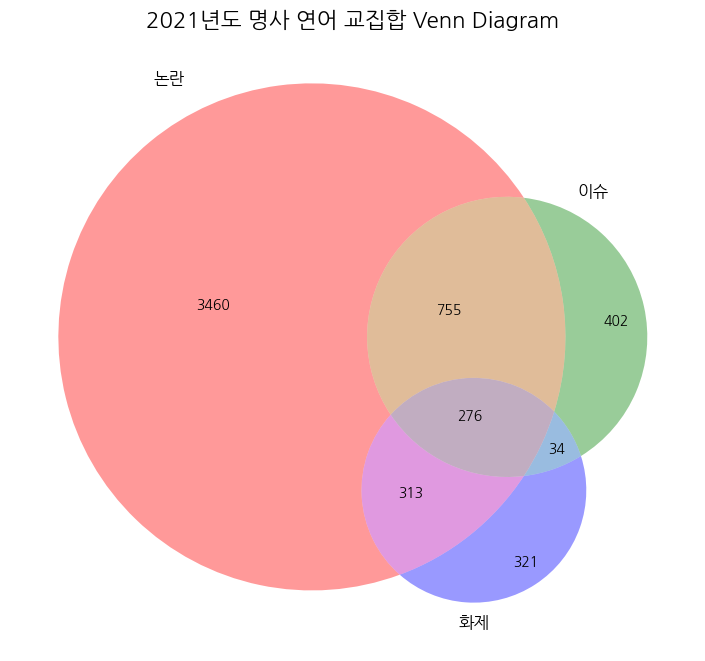

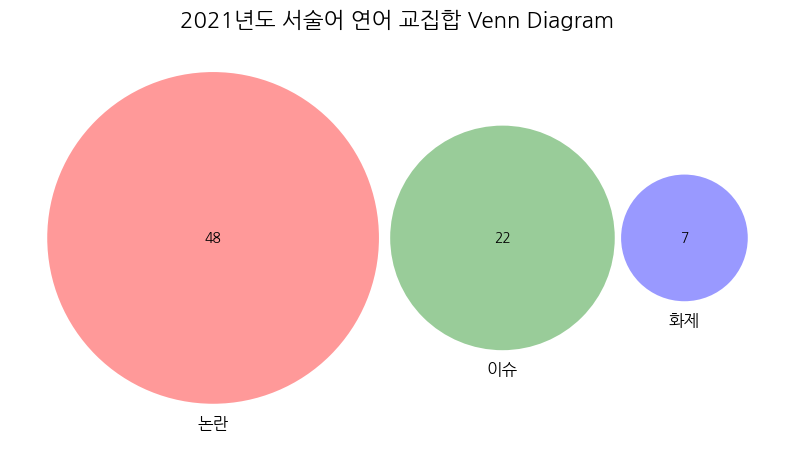

'논란' 연어 추출 중:   0%|          | 0/15271 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/15271 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/2186 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/2186 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1175 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1175 [00:00<?, ?it/s]

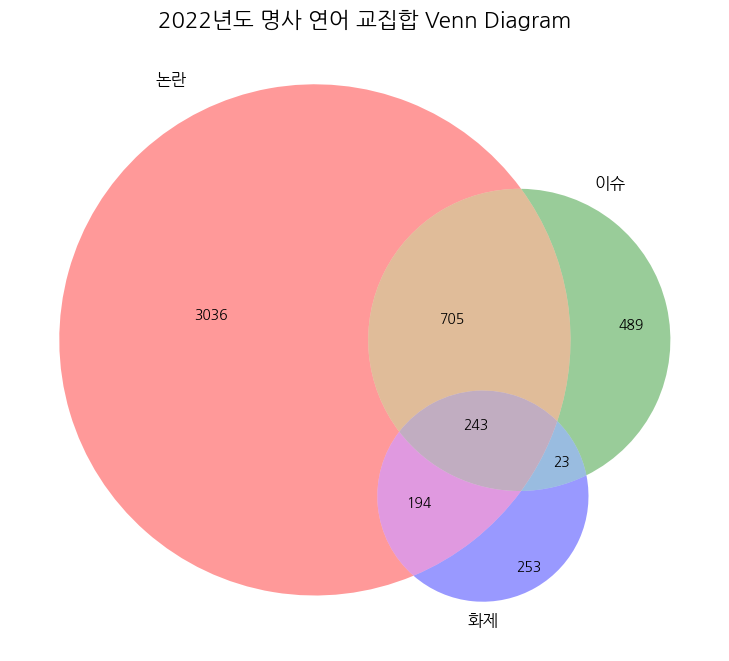

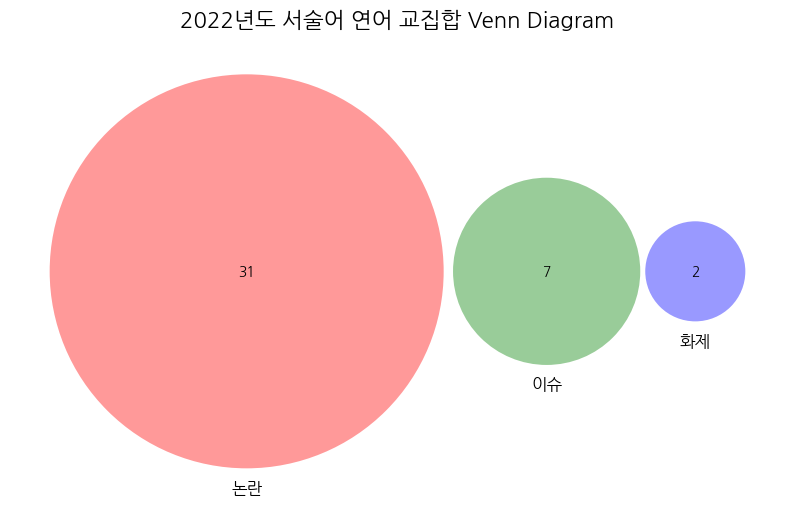

'논란' 연어 추출 중:   0%|          | 0/12859 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/12859 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1825 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1825 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1332 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1332 [00:00<?, ?it/s]

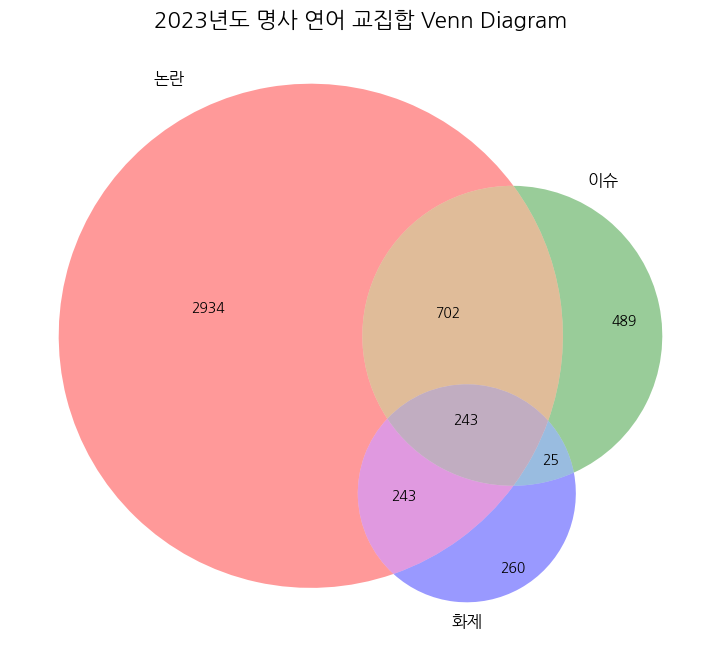

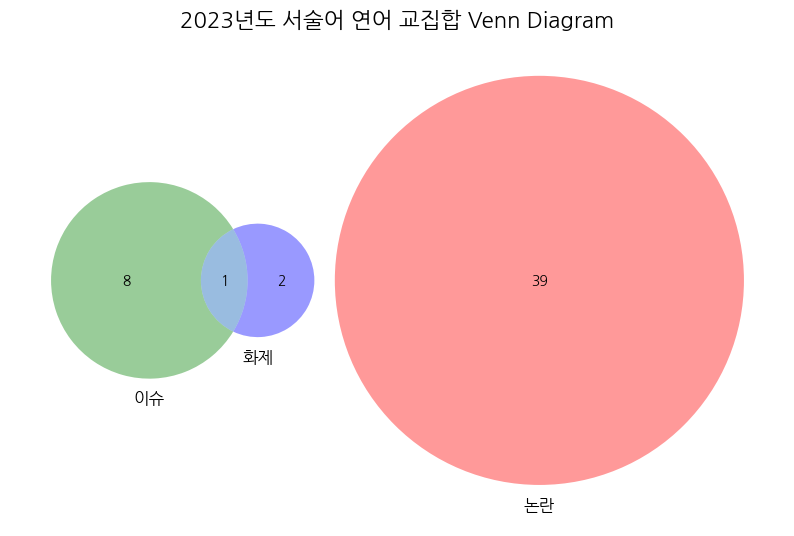

'논란' 연어 추출 중:   0%|          | 0/13109 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/13109 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1635 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1635 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1373 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1373 [00:00<?, ?it/s]

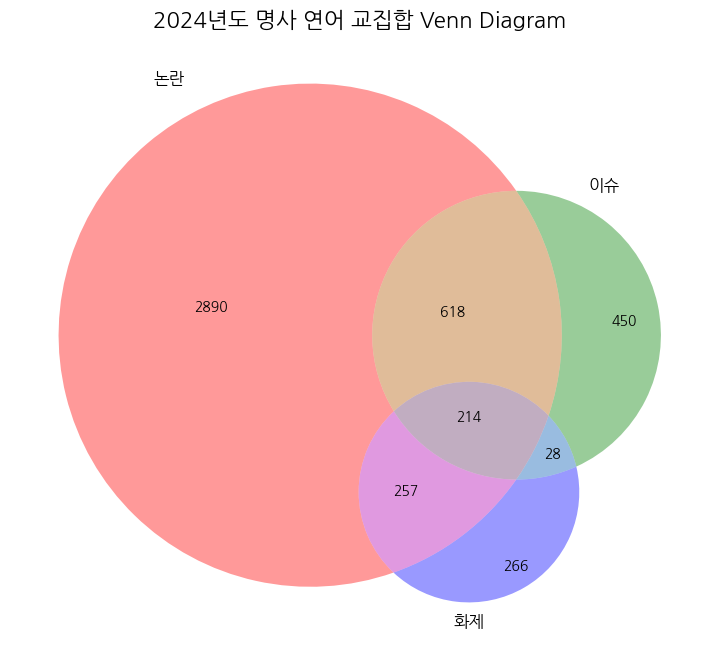

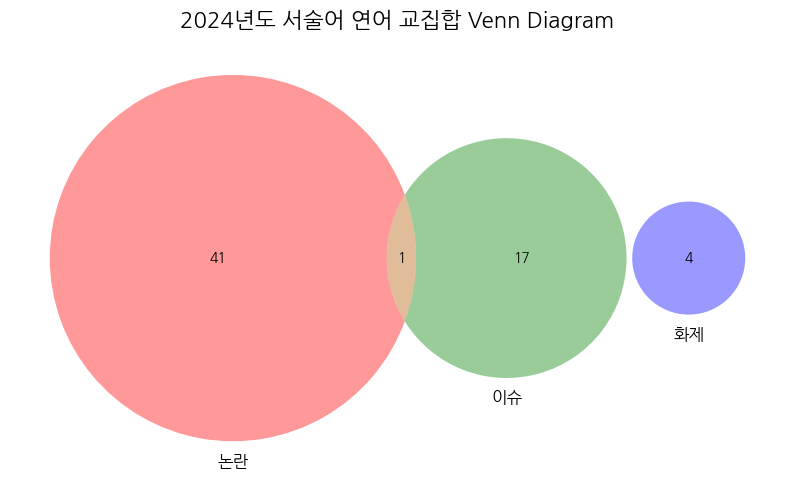

'논란' 연어 추출 중:   0%|          | 0/12539 [00:00<?, ?it/s]

'논란' 연어 추출 중:   0%|          | 0/12539 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1329 [00:00<?, ?it/s]

'이슈' 연어 추출 중:   0%|          | 0/1329 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1302 [00:00<?, ?it/s]

'화제' 연어 추출 중:   0%|          | 0/1302 [00:00<?, ?it/s]

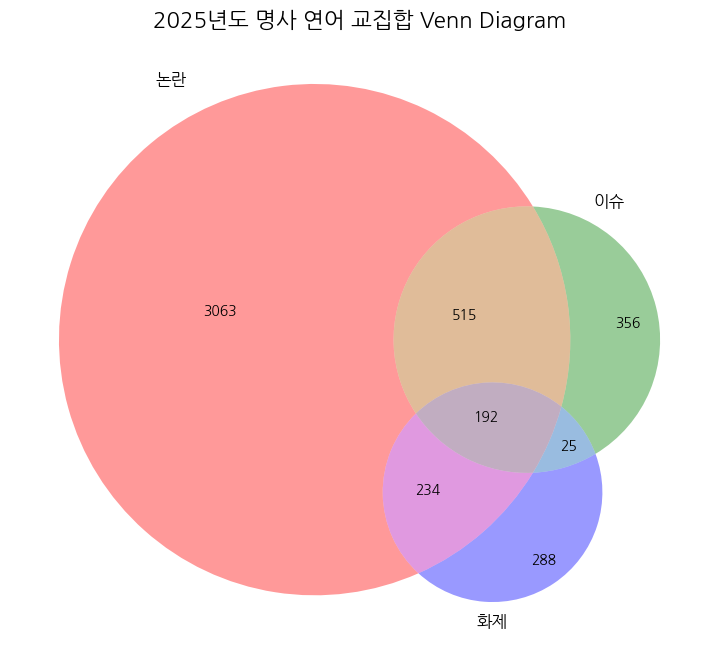

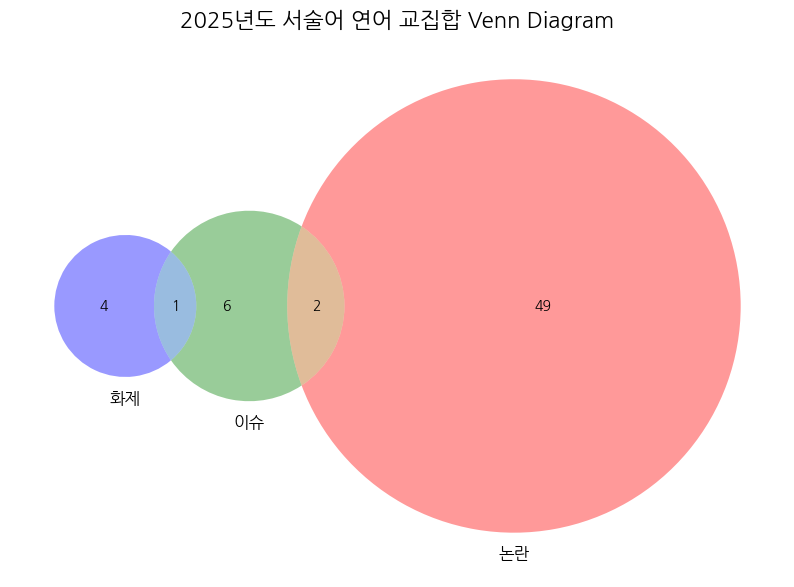


## 연도별 연어 교집합 Venn Diagram 시계열 분석 완료.


In [15]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
from collections import Counter
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# matplotlib-venn 라이브러리 설치 (필요시)
!pip install matplotlib-venn > /dev/null

# ensure the `okt` (Okt tagger) and `extract_collocations` function are available
# from previous cells, as well as `nfc_keywords`, `stopwords_list`, `predicate_stopwords_list` and `all_dfs`

# 폰트 설정 다시 확인
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("\n## 연도별 연어 교집합 Venn Diagram 시계열 분석 시작")

# 사용 가능한 모든 연도 추출
available_years = sorted(list(all_dfs[nfc_keywords[0]].keys())) if nfc_keywords and nfc_keywords[0] in all_dfs else []

if not available_years:
    print("경고: 분석할 연도별 데이터가 없습니다. all_dfs 변수를 확인해주세요.")
else:
    for year in tqdm(available_years, desc="연도별 Venn Diagram 생성 중", leave=True):
        yearly_noun_collocations = {}
        yearly_predicate_collocations = {}

        # 1. 각 키워드별 연도별 명사 및 서술어 연어 추출
        # (tqdm in extract_collocations will be suppressed by leave=False in the outer tqdm loop)
        for keyword in nfc_keywords:
            if keyword in all_dfs and year in all_dfs[keyword] and '추출된_문장' in all_dfs[keyword][year]:
                sentences_for_year = all_dfs[keyword][year]['추출된_문장']

                # 명사 연어
                noun_collocations = extract_collocations(
                    sentences_for_year,
                    target_keyword=keyword,
                    window_size=3,
                    pos_filter=['Noun'],
                    direction='both',
                    stopwords=stopwords_list
                )
                yearly_noun_collocations[keyword] = noun_collocations

                # 서술어 연어
                predicate_collocations = extract_collocations(
                    sentences_for_year,
                    target_keyword=keyword,
                    window_size=1,
                    pos_filter=['Verb', 'Adjective'],
                    direction='after',
                    stopwords=predicate_stopwords_list
                )
                yearly_predicate_collocations[keyword] = predicate_collocations
            else:
                print(f"경고: '{keyword}' 키워드의 {year}년도 데이터가 없거나 '추출된_문장' 컬럼이 없습니다. 해당 연어 추출을 건너뜁니다.")
                yearly_noun_collocations[keyword] = Counter() # 빈 Counter로 초기화
                yearly_predicate_collocations[keyword] = Counter() # 빈 Counter로 초기화

        # Counter 객체를 집합으로 변환 (존재하는 키워드만)
        noun_sets = {kw: set(c.keys()) for kw, c in yearly_noun_collocations.items() if c}
        predicate_sets = {kw: set(c.keys()) for kw, c in yearly_predicate_collocations.items() if c}

        if len(noun_sets) == 3:
            # 명사 연어 Venn Diagram
            plt.figure(figsize=(10, 8))
            venn3([noun_sets['논란'], noun_sets['이슈'], noun_sets['화제']],
                  set_labels=('논란', '이슈', '화제'))
            plt.title(f'{year}년도 명사 연어 교집합 Venn Diagram', fontsize=16)
            plt.show()
        else:
            print(f"{year}년도 명사 연어 Venn Diagram을 그릴 키워드 데이터가 충분하지 않습니다 (논란, 이슈, 화제 모두 필요). ")

        if len(predicate_sets) == 3:
            # 서술어 연어 Venn Diagram
            plt.figure(figsize=(10, 8))
            venn3([predicate_sets['논란'], predicate_sets['이슈'], predicate_sets['화제']],
                  set_labels=('논란', '이슈', '화제'))
            plt.title(f'{year}년도 서술어 연어 교집합 Venn Diagram', fontsize=16)
            plt.show()
        else:
            print(f"{year}년도 서술어 연어 Venn Diagram을 그릴 키워드 데이터가 충분하지 않습니다 (논란, 이슈, 화제 모두 필요).")

print("\n## 연도별 연어 교집합 Venn Diagram 시계열 분석 완료.")

### 4-2. 감성 관계 기반 경계 분석


## 감성 경계 분석: Jensen-Shannon Divergence 및 시계열 분석 시작
Jensen-Shannon Divergence 계산 함수 정의 완료.

연도별 감성 분포 코사인 유사도 및 Jensen-Shannon Divergence 계산 중...

연도별 코사인 유사도 결과:


,연도,키워드 쌍,코사인 유사도
0,2018,논란-이슈,0.530600
1,2018,논란-화제,0.537710
2,2018,이슈-화제,0.999534
3,2019,논란-이슈,0.583443
4,2019,논란-화제,0.529700
5,2019,이슈-화제,0.997276
6,2020,논란-이슈,0.558943
7,2020,논란-화제,0.512649
8,2020,이슈-화제,0.997538
9,2021,논란-이슈,0.515452



연도별 Jensen-Shannon Divergence 결과:


,연도,키워드 쌍,JSD
0,2018,논란-이슈,0.274428
1,2018,논란-화제,0.272774
2,2018,이슈-화제,0.006140
3,2019,논란-이슈,0.221002
4,2019,논란-화제,0.287604
5,2019,이슈-화제,0.013627
6,2020,논란-이슈,0.242628
7,2020,논란-화제,0.307129
8,2020,이슈-화제,0.014403
9,2021,논란-이슈,0.289175



### 연도별 감성 분포 코사인 유사도 시계열


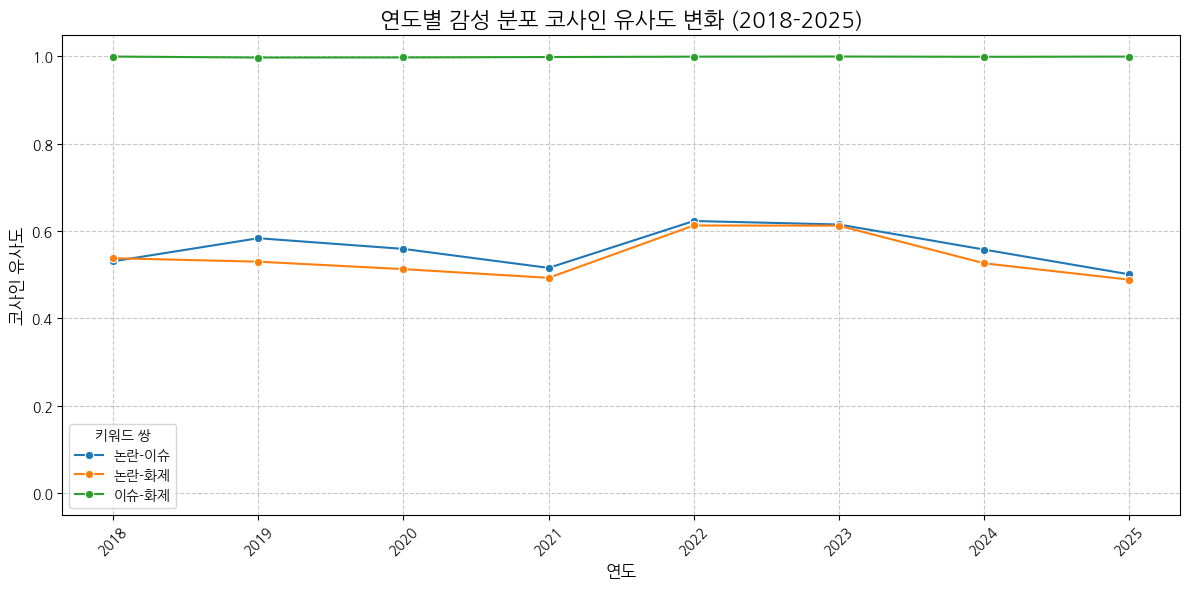


### 연도별 감성 분포 Jensen-Shannon Divergence 시계열


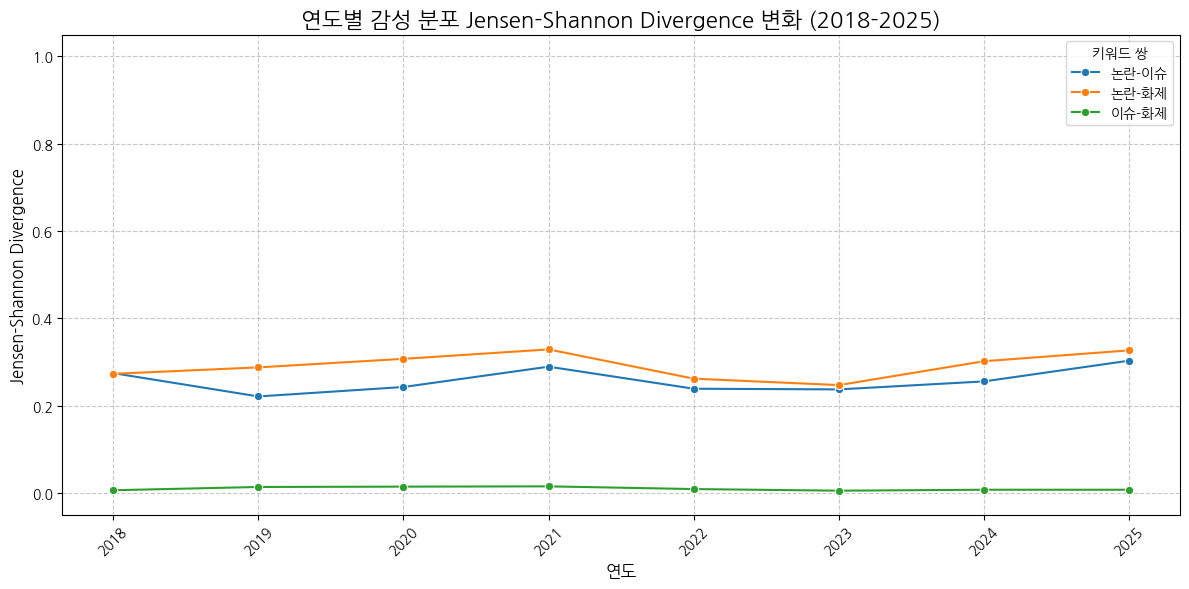


## 감성 경계 분석 완료.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

# 폰트 설정 재확인
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("\n## 감성 경계 분석: Jensen-Shannon Divergence 및 시계열 분석 시작")

# --- 2. 감성 거리 기반 경계 분석: Jensen-Shannon Divergence 구현 ---

def calculate_jensen_shannon_divergence(p, q):
    """
    두 확률 분포 p, q 간의 Jensen-Shannon Divergence를 계산합니다.
    JSD는 두 분포가 얼마나 다른지 측정하며, 0이면 완전히 동일함을 의미합니다.
    """
    # 확률 분포의 합이 1이 되도록 정규화 (부동소수점 오차 보정)
    p = np.array(p, dtype=float) / np.sum(p)
    q = np.array(q, dtype=float) / np.sum(q)

    # JSD 계산 (scipy.spatial.distance.jensenshannon는 sqrt(JSD)를 반환하므로 제곱하여 사용)
    # jensenshannon 함수는 입력이 0인 경우를 자동으로 처리합니다.
    return jensenshannon(p, q, base=2.0) ** 2

print("Jensen-Shannon Divergence 계산 함수 정의 완료.")

# --- 3. 시계열 감성 경계 분석: 연도별 감성 분포 변화 및 프레임 간 거리 변화 추적 ---

# sentiment_results에서 연도별 감성 분포 데이터를 가져옵니다.
# sentiment_df (cell w0PoxfE0Wn07에서 생성됨)를 사용하여 연도별 감성 벡터 생성

# 모든 키워드에 대한 연도별 감성 분포를 저장할 딕셔너리
yearly_sentiment_vectors = {}

for keyword in nfc_keywords:
    yearly_sentiment_vectors[keyword] = {}
    if keyword in sentiment_results:
        for year in sorted(sentiment_results[keyword].keys()):
            df = sentiment_results[keyword][year]
            if df is not None and '감성' in df.columns:
                sentiment_counts = df['감성'].value_counts(normalize=True).reindex(['긍정', '중립', '부정'], fill_value=0)
                yearly_sentiment_vectors[keyword][year] = sentiment_counts.values

# 연도별 유사도/거리 결과를 저장할 리스트
yearly_similarity_results = []
yearly_jsd_results = []

keyword_pairs = [('논란', '이슈'), ('논란', '화제'), ('이슈', '화제')]

print("\n연도별 감성 분포 코사인 유사도 및 Jensen-Shannon Divergence 계산 중...")
for year in available_years:
    for kw1, kw2 in keyword_pairs:
        if year in yearly_sentiment_vectors[kw1] and year in yearly_sentiment_vectors[kw2]:
            vec1 = yearly_sentiment_vectors[kw1][year]
            vec2 = yearly_sentiment_vectors[kw2][year]

            # 코사인 유사도 계산
            if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
                cosine_sim = 0.0 # 하나라도 벡터 크기가 0이면 유사도 0
            else:
                cosine_sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

            # Jensen-Shannon Divergence 계산
            jsd = calculate_jensen_shannon_divergence(vec1, vec2)

            yearly_similarity_results.append({
                '연도': year,
                '키워드 쌍': f'{kw1}-{kw2}',
                '코사인 유사도': cosine_sim
            })
            yearly_jsd_results.append({
                '연도': year,
                '키워드 쌍': f'{kw1}-{kw2}',
                'JSD': jsd
            })

yearly_cosine_df = pd.DataFrame(yearly_similarity_results)
yearly_jsd_df = pd.DataFrame(yearly_jsd_results)

print("\n연도별 코사인 유사도 결과:")
display(yearly_cosine_df)

print("\n연도별 Jensen-Shannon Divergence 결과:")
display(yearly_jsd_df)

# --- 시계열 시각화 ---

print("\n### 연도별 감성 분포 코사인 유사도 시계열")
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_cosine_df, x='연도', y='코사인 유사도', hue='키워드 쌍', marker='o')
plt.title('연도별 감성 분포 코사인 유사도 변화 (2018-2025)', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('코사인 유사도', fontsize=12)
plt.xticks(available_years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.05, 1.05) # 유사도 범위
plt.legend(title='키워드 쌍')
plt.tight_layout()
plt.show()

print("\n### 연도별 감성 분포 Jensen-Shannon Divergence 시계열")
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_jsd_df, x='연도', y='JSD', hue='키워드 쌍', marker='o')
plt.title('연도별 감성 분포 Jensen-Shannon Divergence 변화 (2018-2025)', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('Jensen-Shannon Divergence', fontsize=12)
plt.xticks(available_years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.05, 1.05) # JSD는 0과 1 사이 값 (log base 2)
plt.legend(title='키워드 쌍')
plt.tight_layout()
plt.show()

print("\n## 감성 경계 분석 완료.")
